# Stack Bar Chart

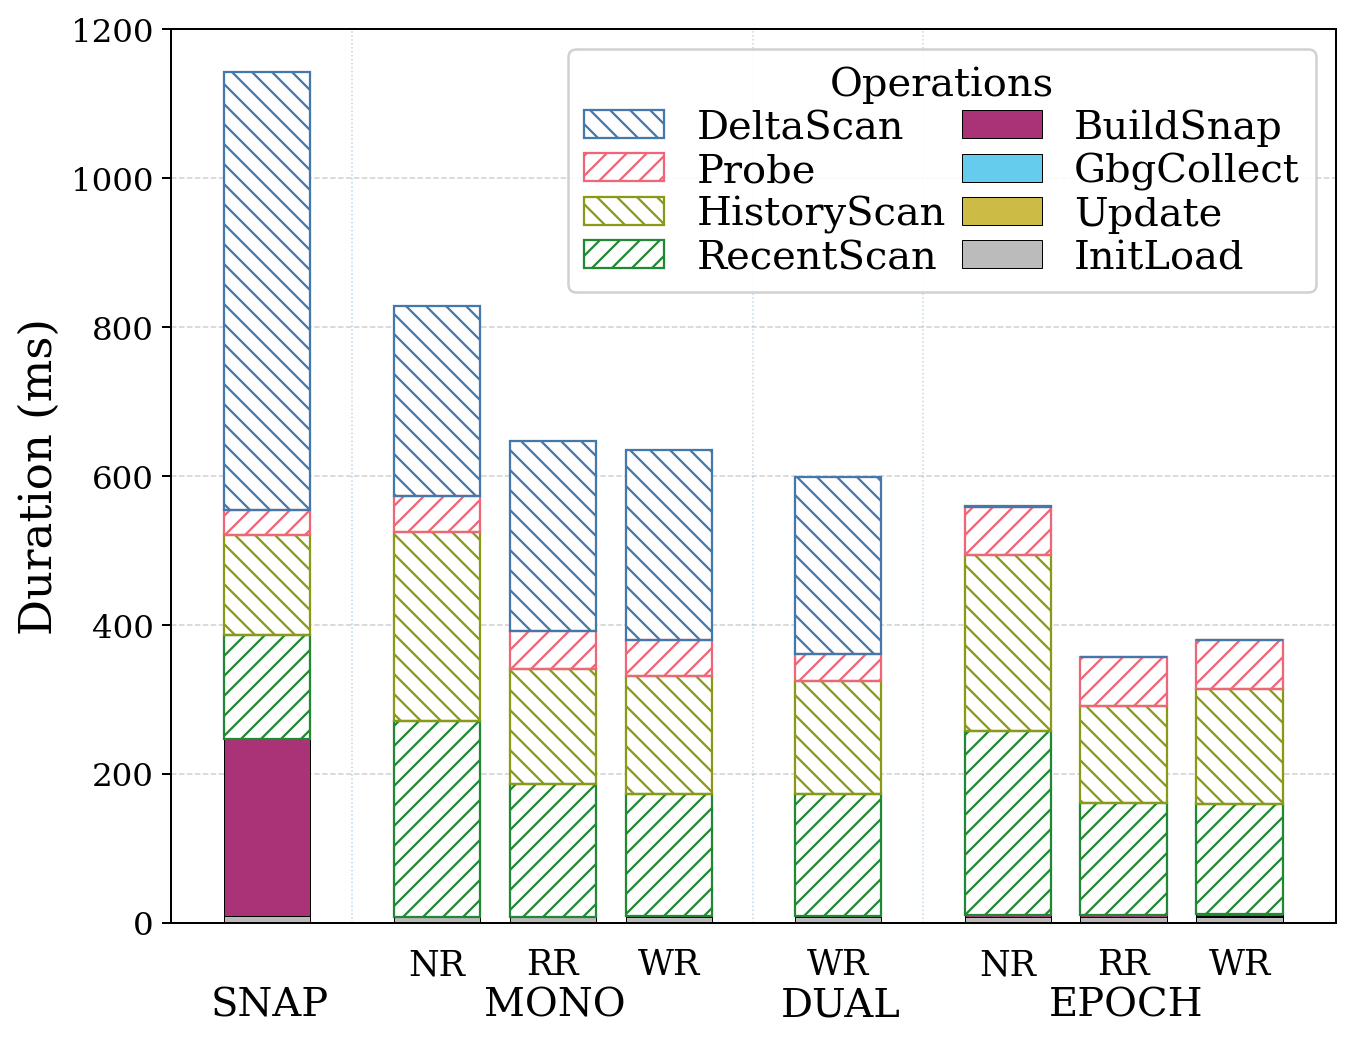

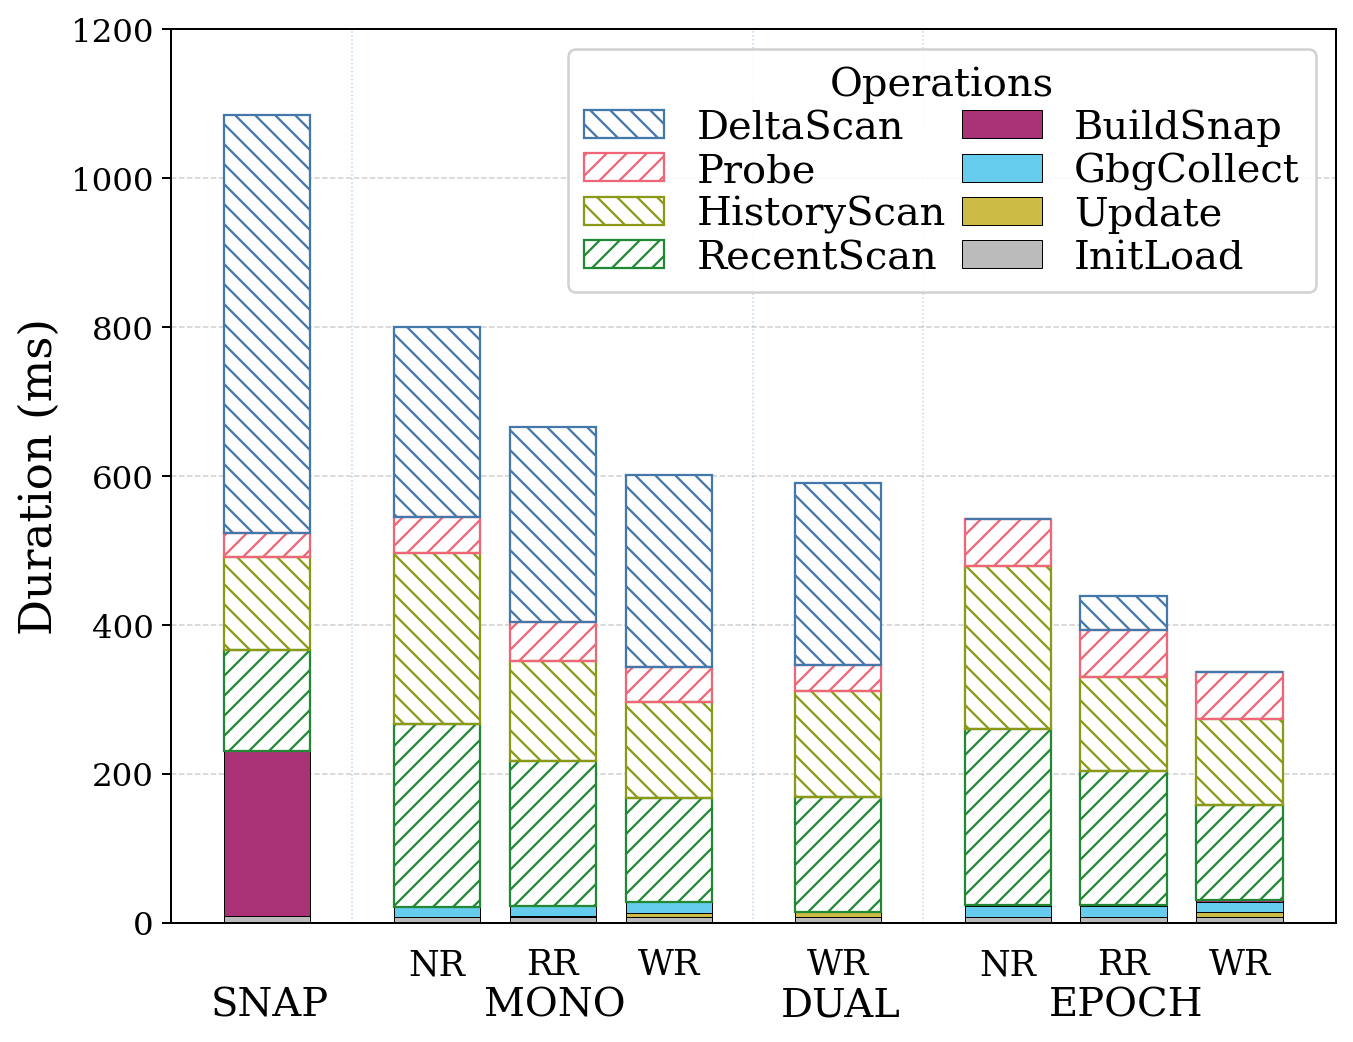

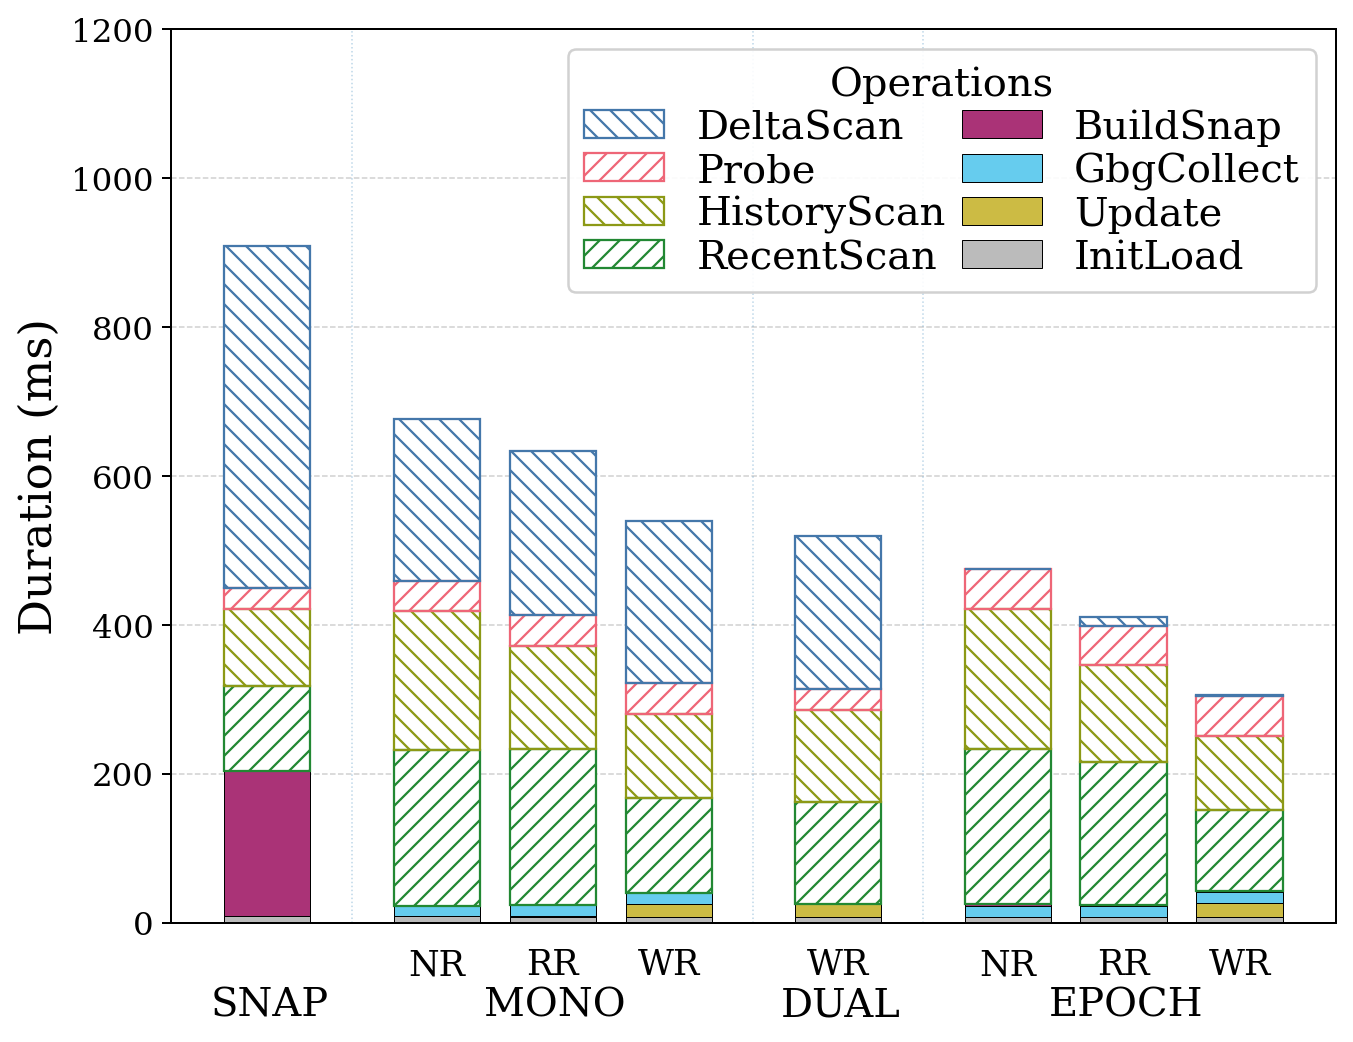

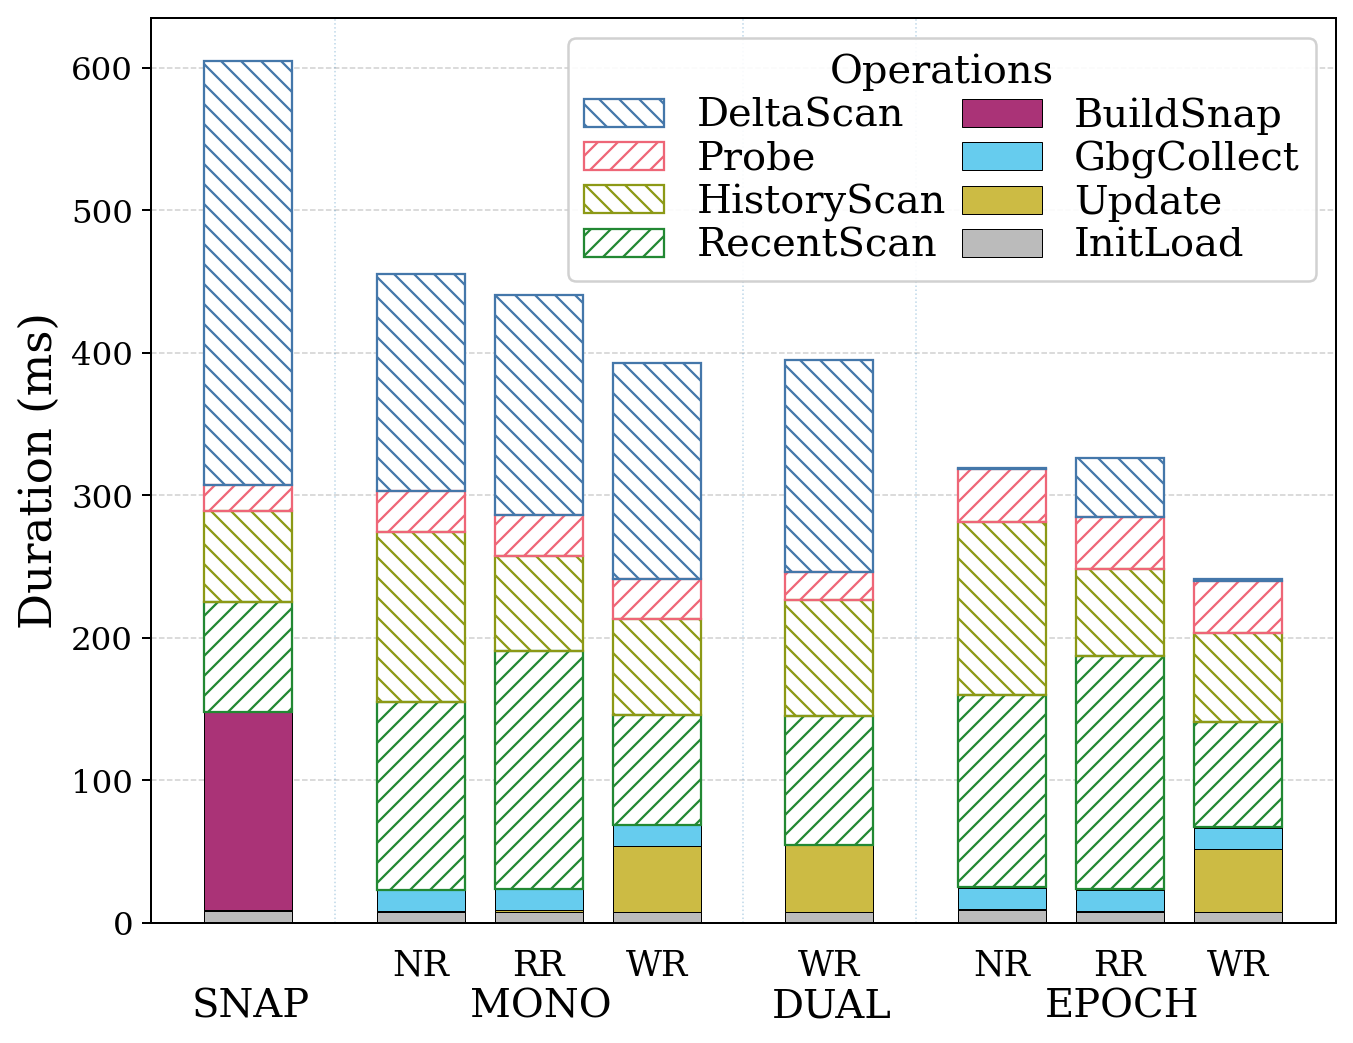

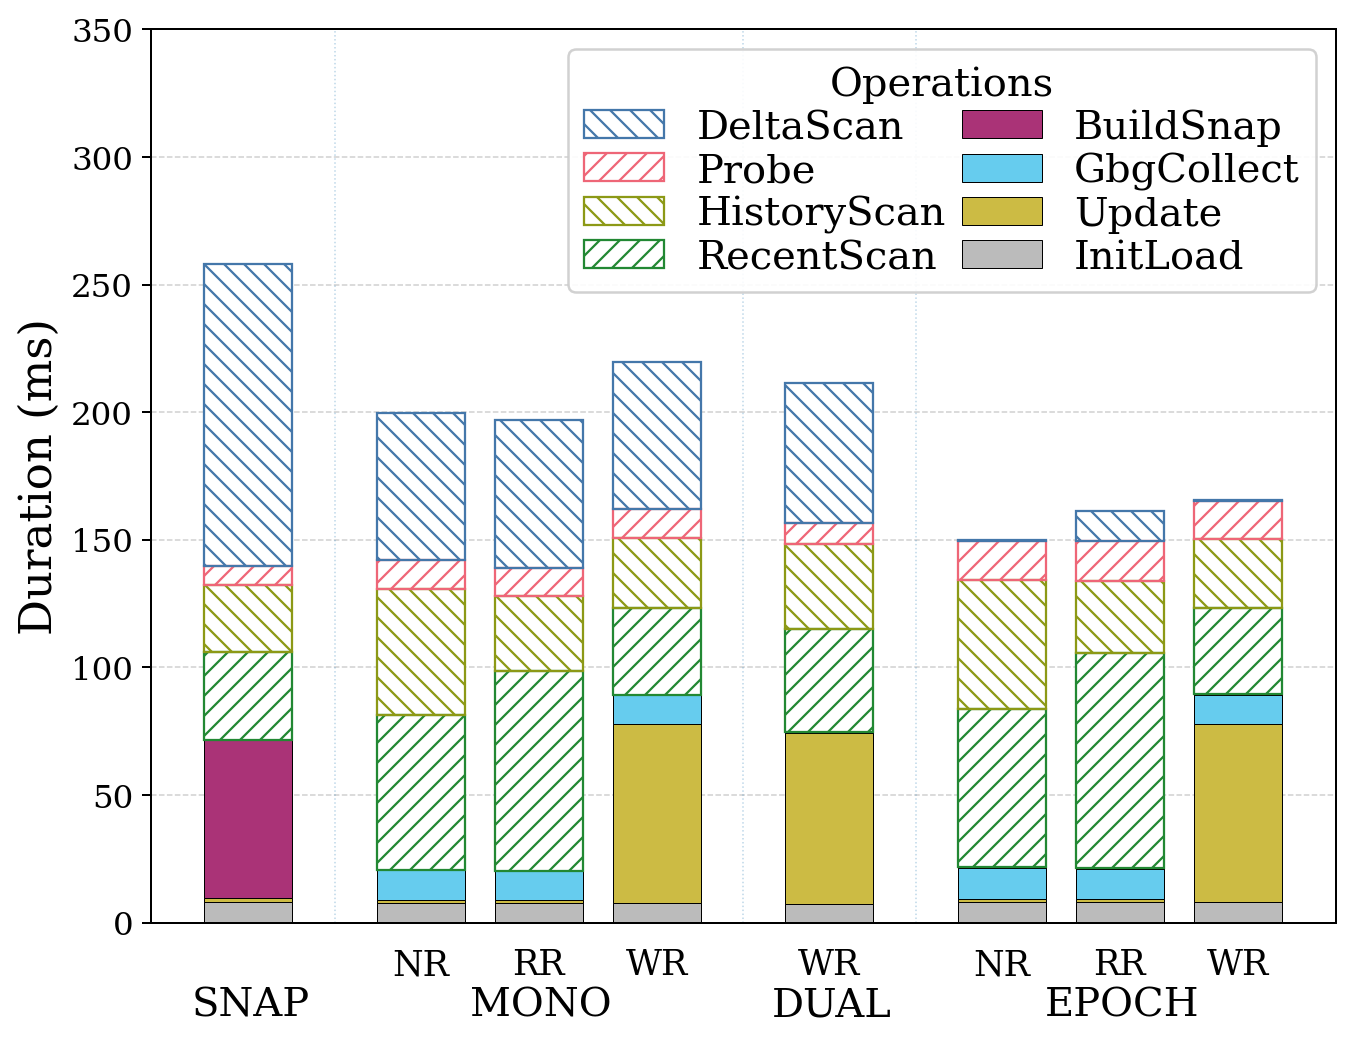

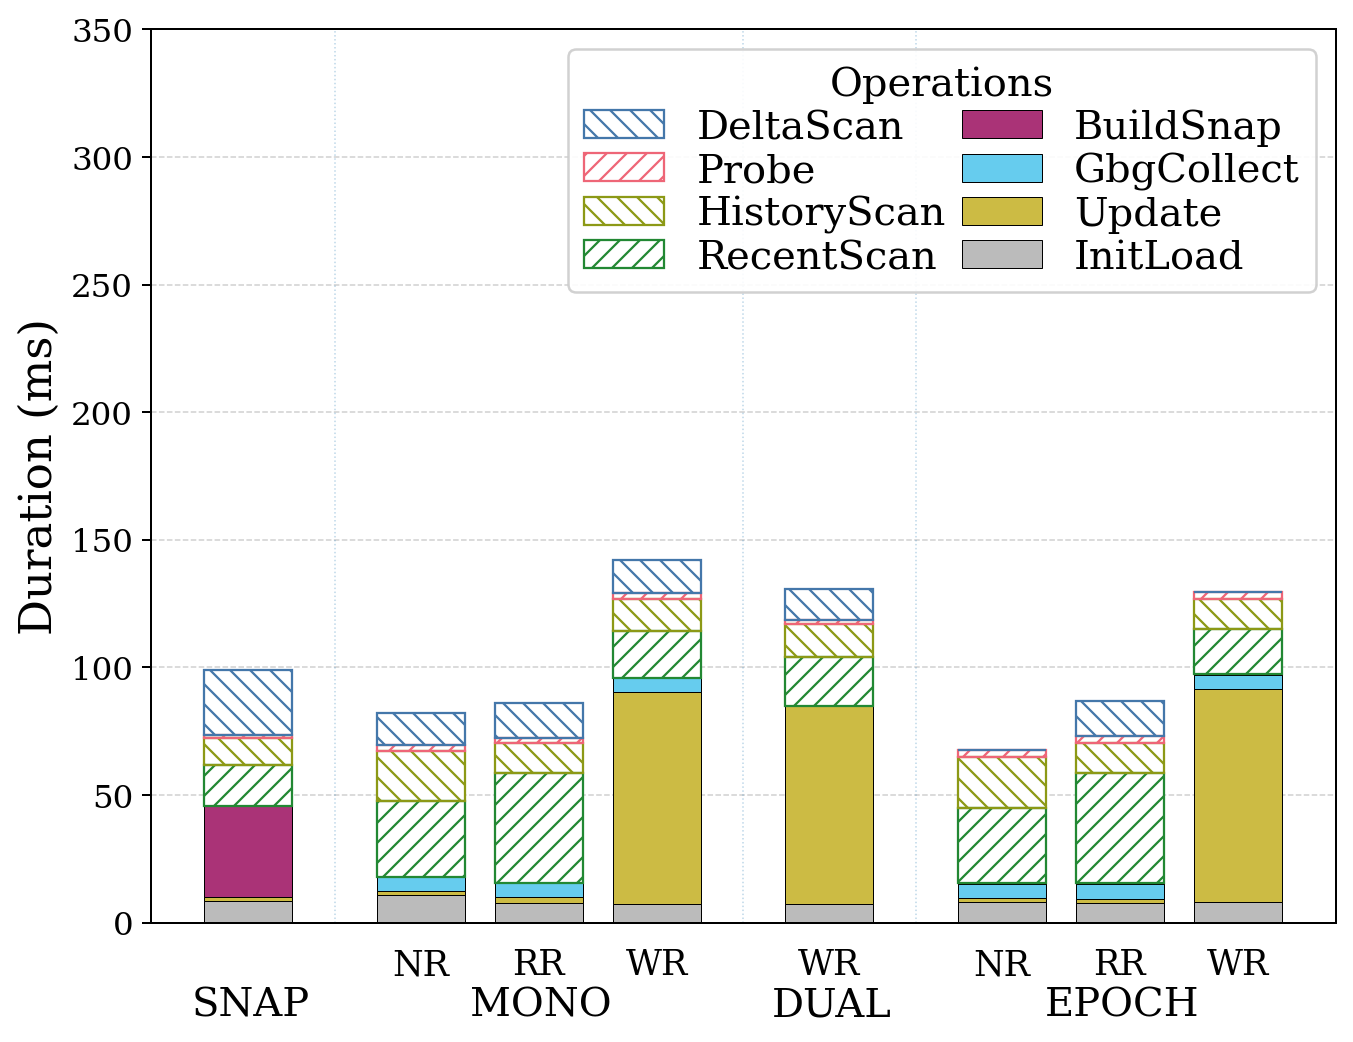

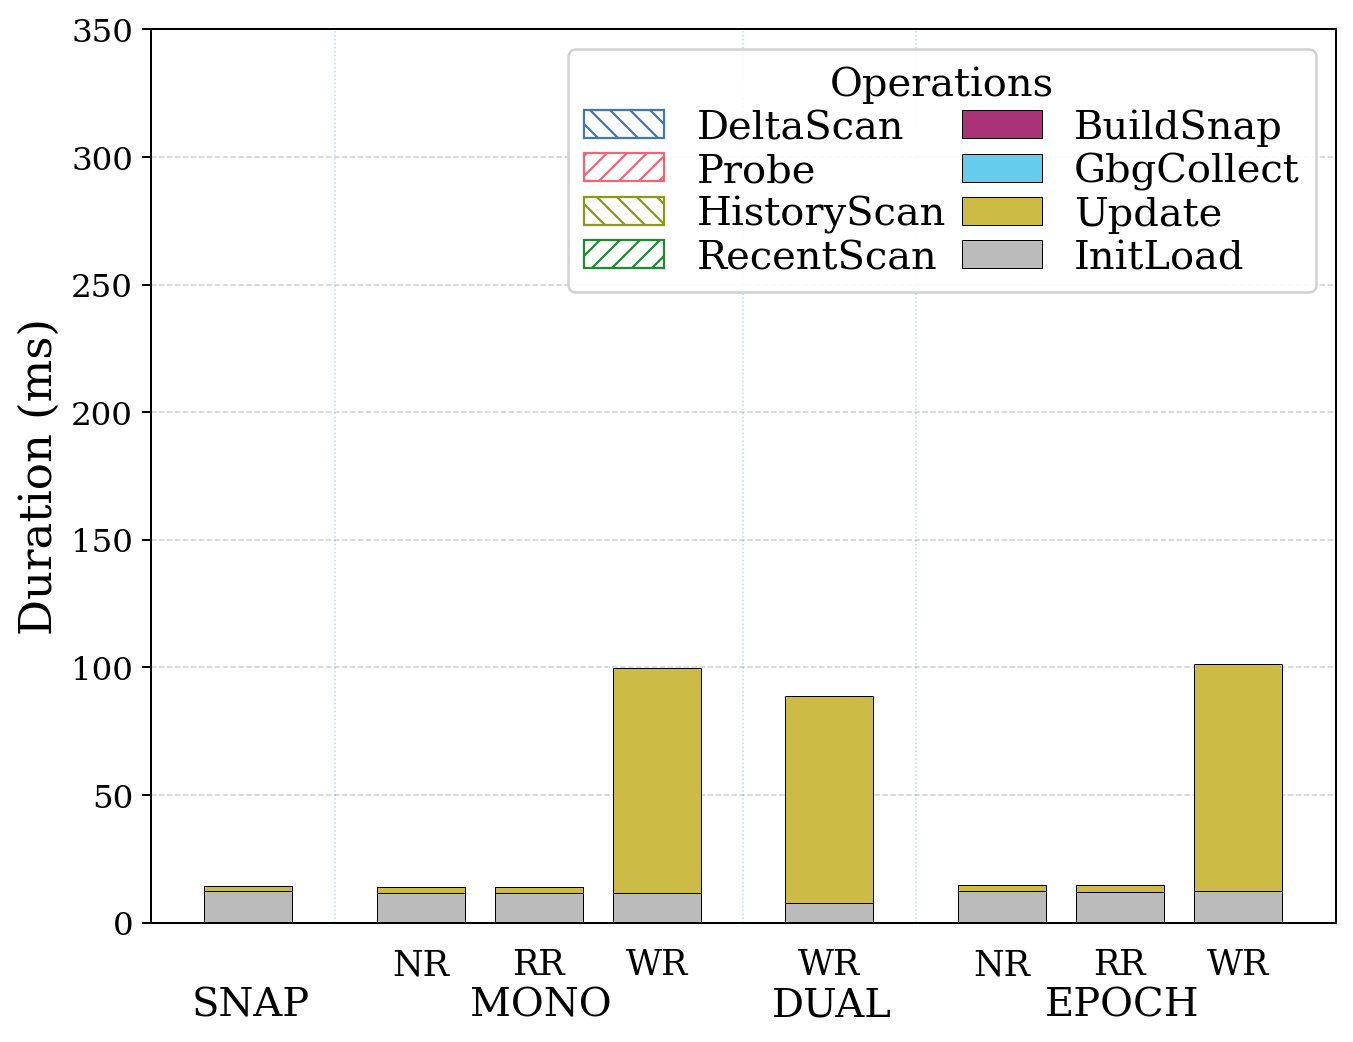

In [ ]:
# Self-contained: paste into a cell and run.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import pandas as pd

bold = "normal"


TX_MAP = {
    "MarkTs": "BuildSnap",
    "DelSc": "DeltaScan",
}
plt.rcParams["font.size"] = 16          # 默认字体
plt.rcParams["axes.labelsize"] = 18     # 坐标轴标题
plt.rcParams["xtick.labelsize"] = 13    # x轴刻度
plt.rcParams["ytick.labelsize"] = 13    # y轴刻度
plt.rcParams["legend.fontsize"] = 16    # 图例文字
plt.rcParams["legend.title_fontsize"] = 16
# Times New Roman
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"]  = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["hatch.linewidth"] = 0.9

def draw_grouped_stacked_bar(df, title="R-heavy", subtitle="All Types", path = "output/"):
    # ORDER & DISPLAY NAMES
    table_order   = ["naive", "heap", "chain", "par"]  # data keys
    table_display = {"naive":"SNAP", "heap":"MONO", "chain":"DUAL", "par":"EPOCH"}

    repair_order = {
        "naive": [""],
        "heap":  ["No Repair", "Read Repair", "Write Repair"],
        "chain": ["Write Repair"],
        "par":   ["No Repair", "Read Repair", "Write Repair"],
    }
    repair_display = {"No Repair":"NR", "Read Repair":"RR", "Write Repair":"WR", "": ""}

    # STACK ORDER (bottom -> top)
    tx_order   = ["InitLoad", "Update", "GbgCollect", "BuildSnap", "RecentScan", "HistoryScan", "Probe", "DeltaScan"]
    # MarkTs = WRITE (solid)
    write_like = {"InitLoad", "Update", "GbgCollect", "BuildSnap"}
    read_like  = {"Probe", "RecentScan", "HistoryScan", "DeltaScan"}

    # Paul Tol "Bright" palette
    tol = {
        "blue":   "#4477AA",
        "cyan":   "#66CCEE",
        "green":  "#228833",
        "yellow": "#CCBB44",
        "red":    "#EE6677",
        "purple": "#AA3377",
        "grey":   "#BBBBBB",
        "darkgreen": "#8C9916",
    }

    color_map = {
        "InitLoad":  tol["grey"],
        "Update":    tol["yellow"],
        "GbgCollect":tol["cyan"],
        "BuildSnap":    tol["purple"],
        "Probe":     tol["red"],
        "RecentScan":      tol["green"],
        "HistoryScan":      tol["darkgreen"],
        "DeltaScan":     tol["blue"],
    }

    # READ hatch orientations (alternate): 
    # DelSc: backslash ( \ ), Scan: slash ( / ), Probe: backslash ( \ )
    hatch_read_map = {
        "DeltaScan": "\\\\\\",
        "Probe":  "///",
        "HistoryScan": "\\\\\\",
        "RecentScan": "///",
    }



    # pivot (ms) -> ms
    pvt = (
        df.pivot_table(index=["table_type","repair_type"],
                       columns="tx_type", values="duration_ms",
                       aggfunc="sum", fill_value=0.0)
        .reindex(columns=tx_order, fill_value=0.0)
    )


    # x positions (two-tier labels)
    bar_w = 0.58
    gap   = 0.36
    bar_x, minor_labels, major_centers, major_labels, combos = [], [], [], [], []
    x = 0.0
    for t in table_order:
        subs = repair_order[t]
        start = x
        for r in subs:
            bar_x.append(x)
            minor_labels.append(repair_display[r])  # NR/RR/WR
            combos.append((t, r))
            x += 0.78
        end = x - 0.75 # 1.0
        major_centers.append((start + end) / 2.0)
        major_labels.append(table_display[t])
        x += gap

    # slightly taller aspect ratio
    fig, ax = plt.subplots(figsize=(7.8, 6.0))
    fig.subplots_adjust(bottom=0.22)

    # stacked bars
    for i, (t, r) in enumerate(combos):
        row = pvt.loc[(t, r)] if (t, r) in pvt.index else pd.Series(0.0, index=tx_order)
        bottom = 0.0
        for tx in tx_order:
            v = float(row.get(tx, 0.0))
            if v <= 0:
                continue
            if tx in write_like:
                # WRITE: solid
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color=color_map[tx], edgecolor="black", linewidth=0.4, zorder=2
                )
            else:
                # READ: white base + colored hatch overlay (orientation per tx)
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color="white", edgecolor="black", linewidth=0.4, zorder=2
                )
                ax.bar(
                    bar_x[i], v, bottom=bottom, width=bar_w,
                    color="none", edgecolor=color_map[tx], linewidth=0.9,
                    hatch=hatch_read_map.get(tx, "///"), zorder=3
                )
            bottom += v

    # custom x labels (two lines, close to axis)
    ax.set_xticks([])
    for xi, lab in zip(bar_x, minor_labels):
        ax.text(xi, -0.028, lab, ha="center", va="top",
                transform=ax.get_xaxis_transform(), fontsize=14, clip_on=False, fontweight=bold)
    for xc, lab in zip(major_centers, major_labels):
        ax.text(xc, -0.072, lab, ha="center", va="top",
                transform=ax.get_xaxis_transform(), fontsize=16, clip_on=False, fontweight=bold)

    # separators between major groups
    for k in range(1, len(major_centers)):
        prev_end   = max([xx for xx,(tt,_) in zip(bar_x, combos) if tt == table_order[k-1]])
        next_start = min([xx for xx,(tt,_) in zip(bar_x, combos) if tt == table_order[k]])
        ax.axvline((prev_end + next_start)/2, linestyle=":", linewidth=0.6, alpha=0.3)

    # y-axis
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
    ax.set_ylabel("Duration (ms)", fontweight=bold)
    # plt.yticks(fontweight=bold)

    
    if title.startswith('R'):
        ax.set_ylim(top=1200.0)
    elif title.startswith('W'):
        ax.set_ylim(top=350.0)

    # Title (exactly as provided)
    # ax.set_title(title)

    # Legend (manual so READ shows hatch per-op, WRITE are solid), reversed order
    handles, labels = [], []
    for tx in tx_order[::-1]:
        if tx in write_like:
            patch = Patch(facecolor=color_map[tx], edgecolor="black", linewidth=0.4)
        else:
            patch = Patch(facecolor="white", edgecolor=color_map[tx],
                          hatch=hatch_read_map.get(tx, "///"), linewidth=0.9)
        handles.append(patch)
        labels.append(tx)

    # ax.legend(handles, labels, title="Operations",
    #           loc="upper right", framealpha=0.9, fontsize=9, title_fontsize=9)
    bbox_to_anchor = (1.0, 1.0)
    # if title.startswith('W') :
    #     bbox_to_anchor = (0.865, 1.0)

    # ax.legend(
    #     handles, labels, title="Operations",
    #     loc="upper right",
    #     bbox_to_anchor=bbox_to_anchor,   # 默认 (1,1)，往左移到 0.92，可微调
    #     framealpha=0.9,
    #     fontsize=9,
    #     title_fontsize=9
    # )
    leg = ax.legend(
        handles, labels, title="Operations",
        loc="upper right",
        bbox_to_anchor=bbox_to_anchor,
        framealpha=0.9,
        fontsize=16,
        title_fontsize=16,
        ncol=2,              # ✅ 新增：让 legend 分为两列
        columnspacing=0.4,   # ✅ 可选：调节列间距
        labelspacing=0.15     # ✅ 可选：调节行间距
    )
    leg.get_title().set_fontweight(bold)  
    for text in leg.get_texts():             
        text.set_fontweight(bold) 

    
    plt.tight_layout()
    
    plt.savefig(path + title + ".pdf", format="pdf")
    plt.show()

workload_levels = [
    "Analytical Only",
    "Extremely Analytical Heavy",
    "Analytical Heavy",
    "Hybrid",
    "Transactional Heavy",
    "Extremely Transactional Heavy",
    "Transactional Only"
]
workload_title_dict = {
    "Analytical Only": "RO",              # Read Only
    "Extremely Analytical Heavy": "RE",   # Read Extremely Heavy
    "Analytical Heavy": "RH",             # Read Heavy
    "Hybrid": "B",                        # Balanced
    "Transactional Heavy": "WH",          # Write Heavy
    "Extremely Transactional Heavy": "WE",# Write Extremely Heavy
    "Transactional Only": "WO"            # Write Only
}

TXN_NUM = 100

for wkld in workload_levels:
    df_name = "output/" + "(UNIFORM-ANALYTICAL) " + wkld + "_result.csv"
    # Load CSV into a DataFrame
    df = pd.read_csv(df_name)
    df["duration_ms"] = df["duration_ms"] / TXN_NUM
    # display(df)
    df["tx_type"] = df["tx_type"].replace(TX_MAP)
    df.loc[df["table_type"] == "naive", "repair_type"] = ""
    draw_grouped_stacked_bar(df, title=workload_title_dict[wkld], subtitle="All Types", path="output/")

# LINE PLOT

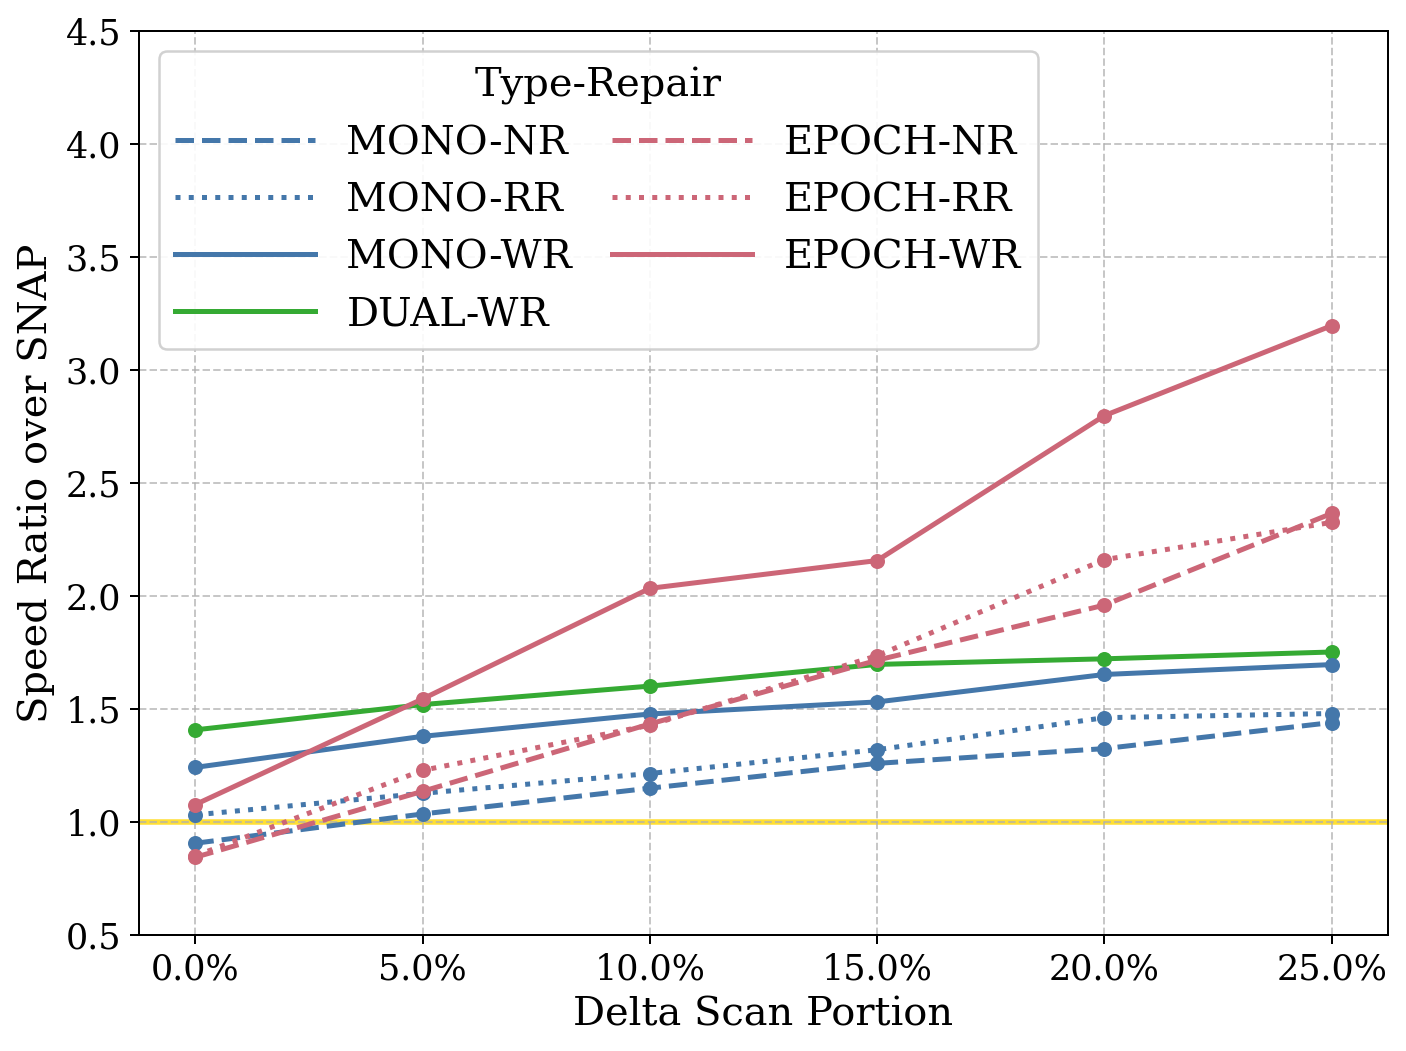

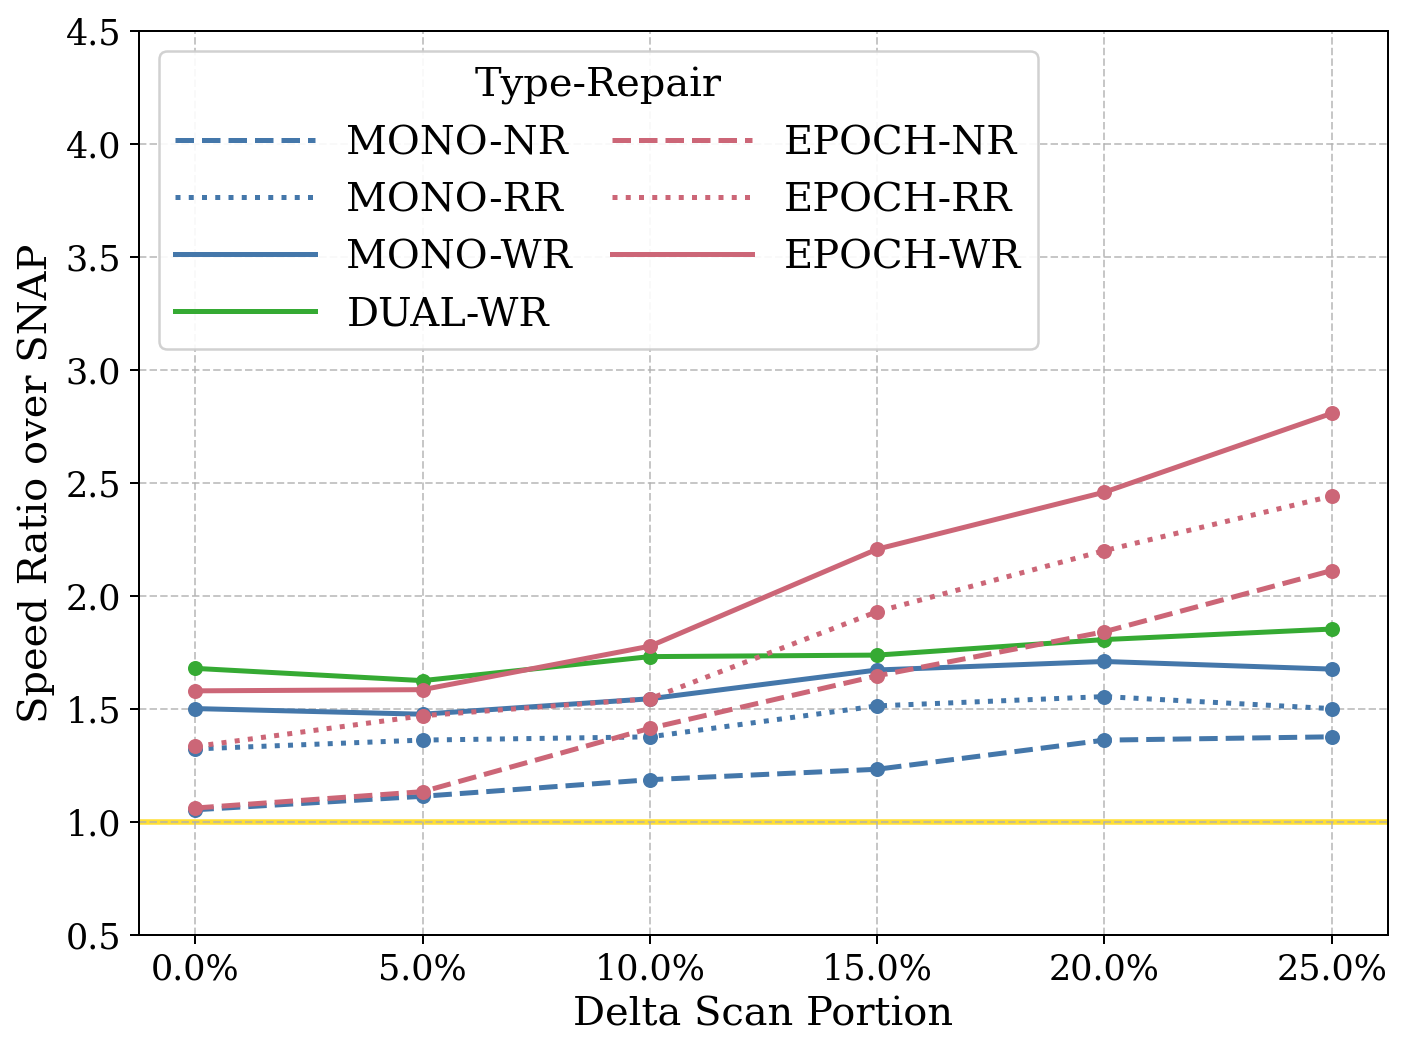

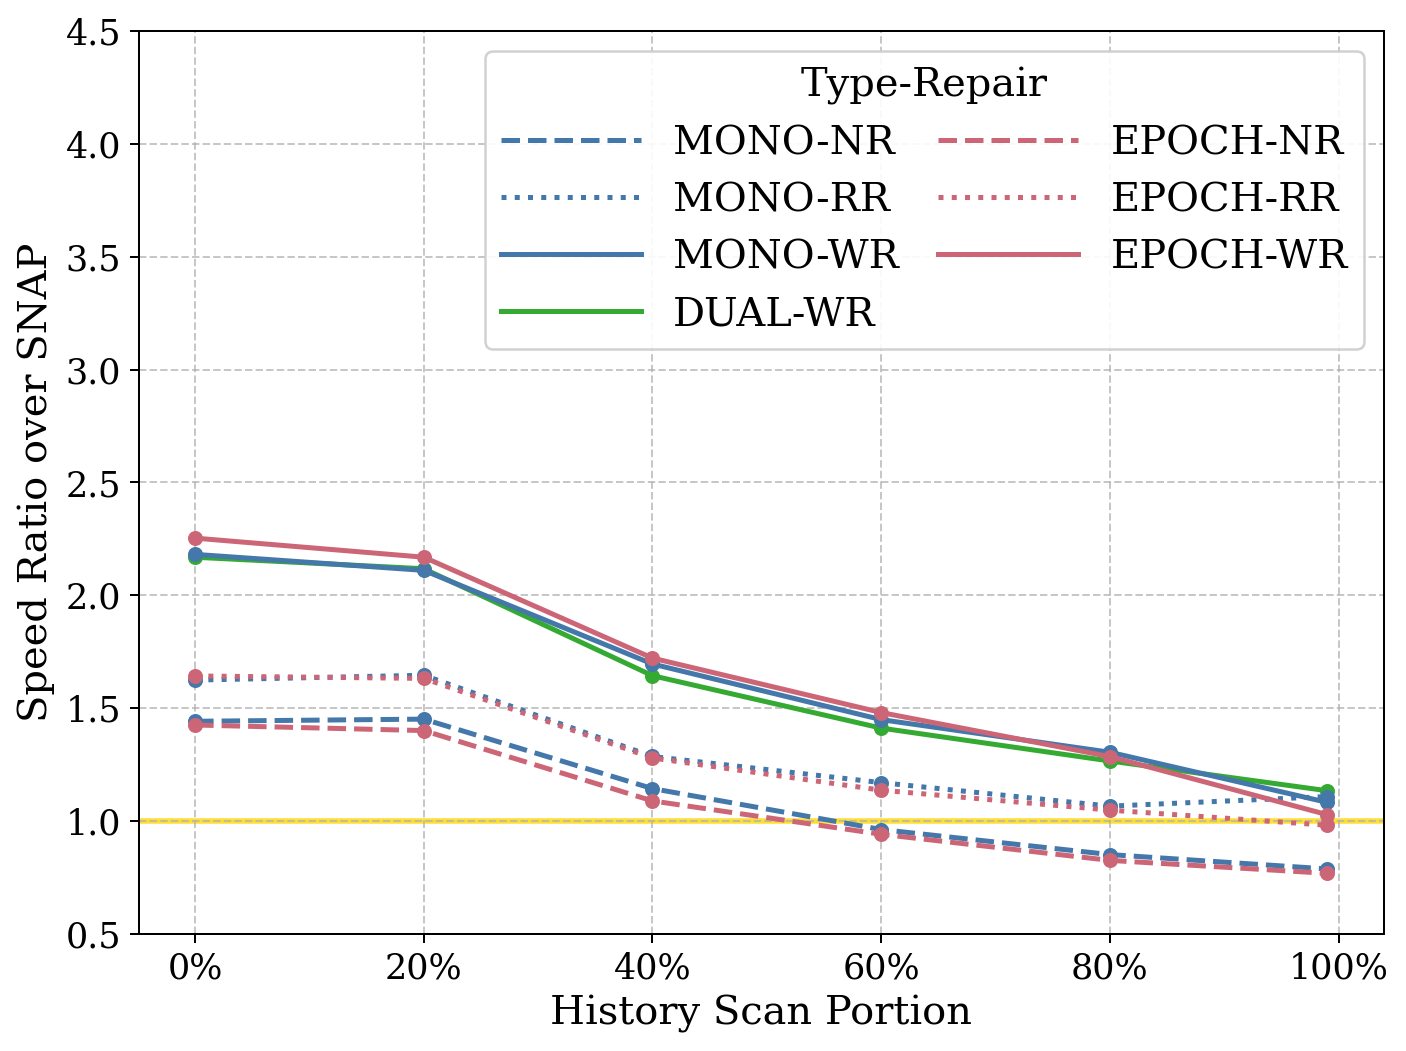

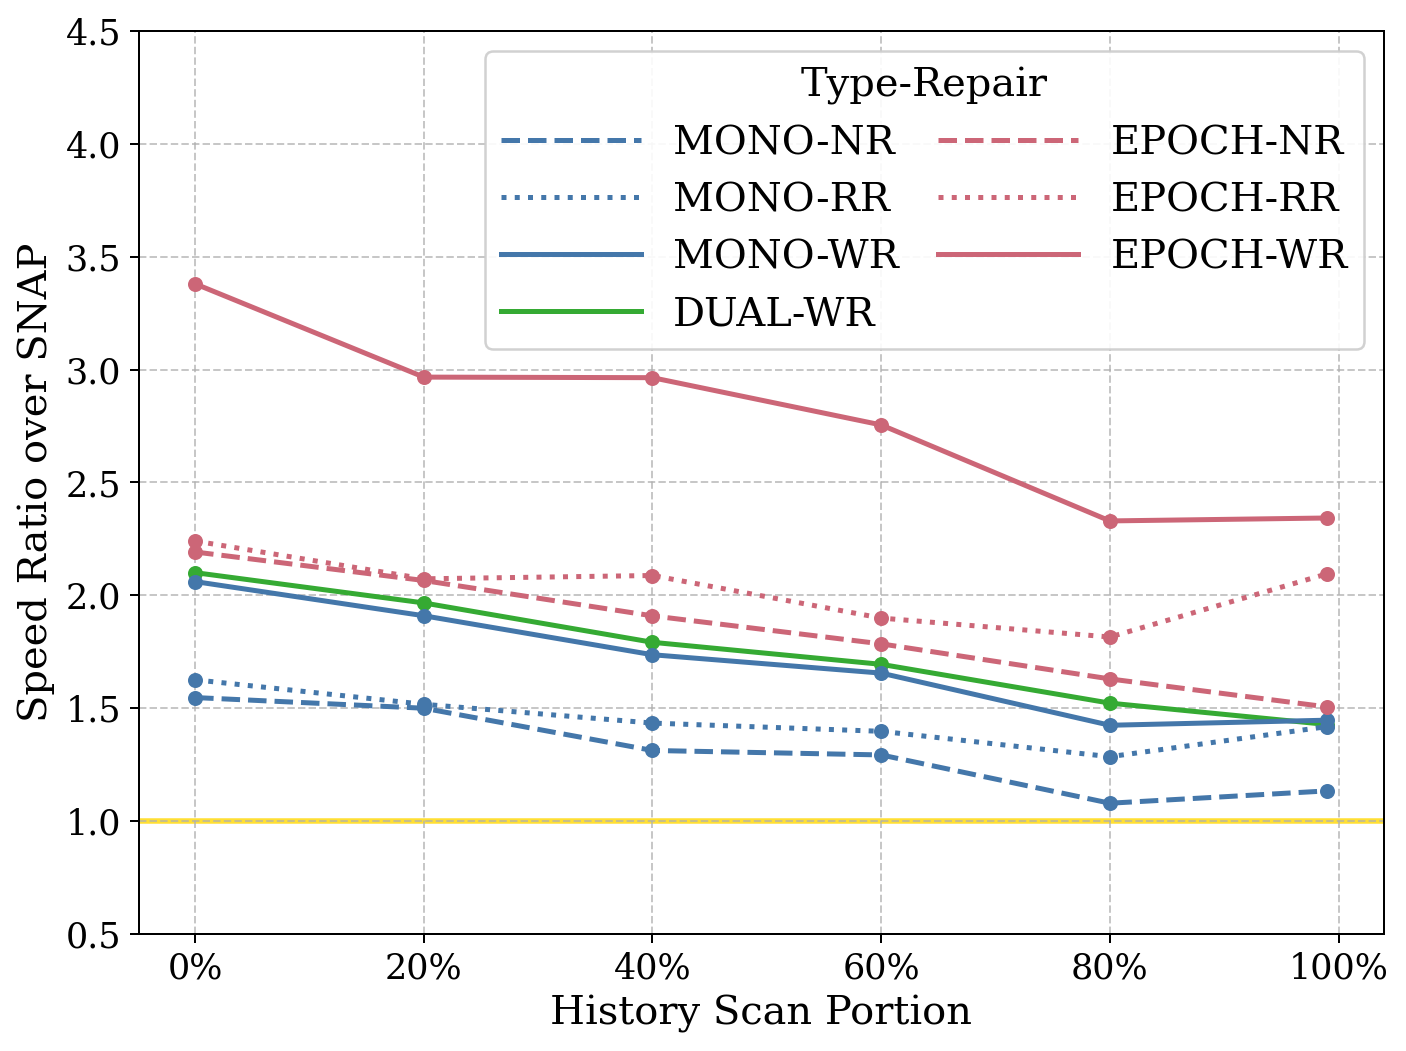

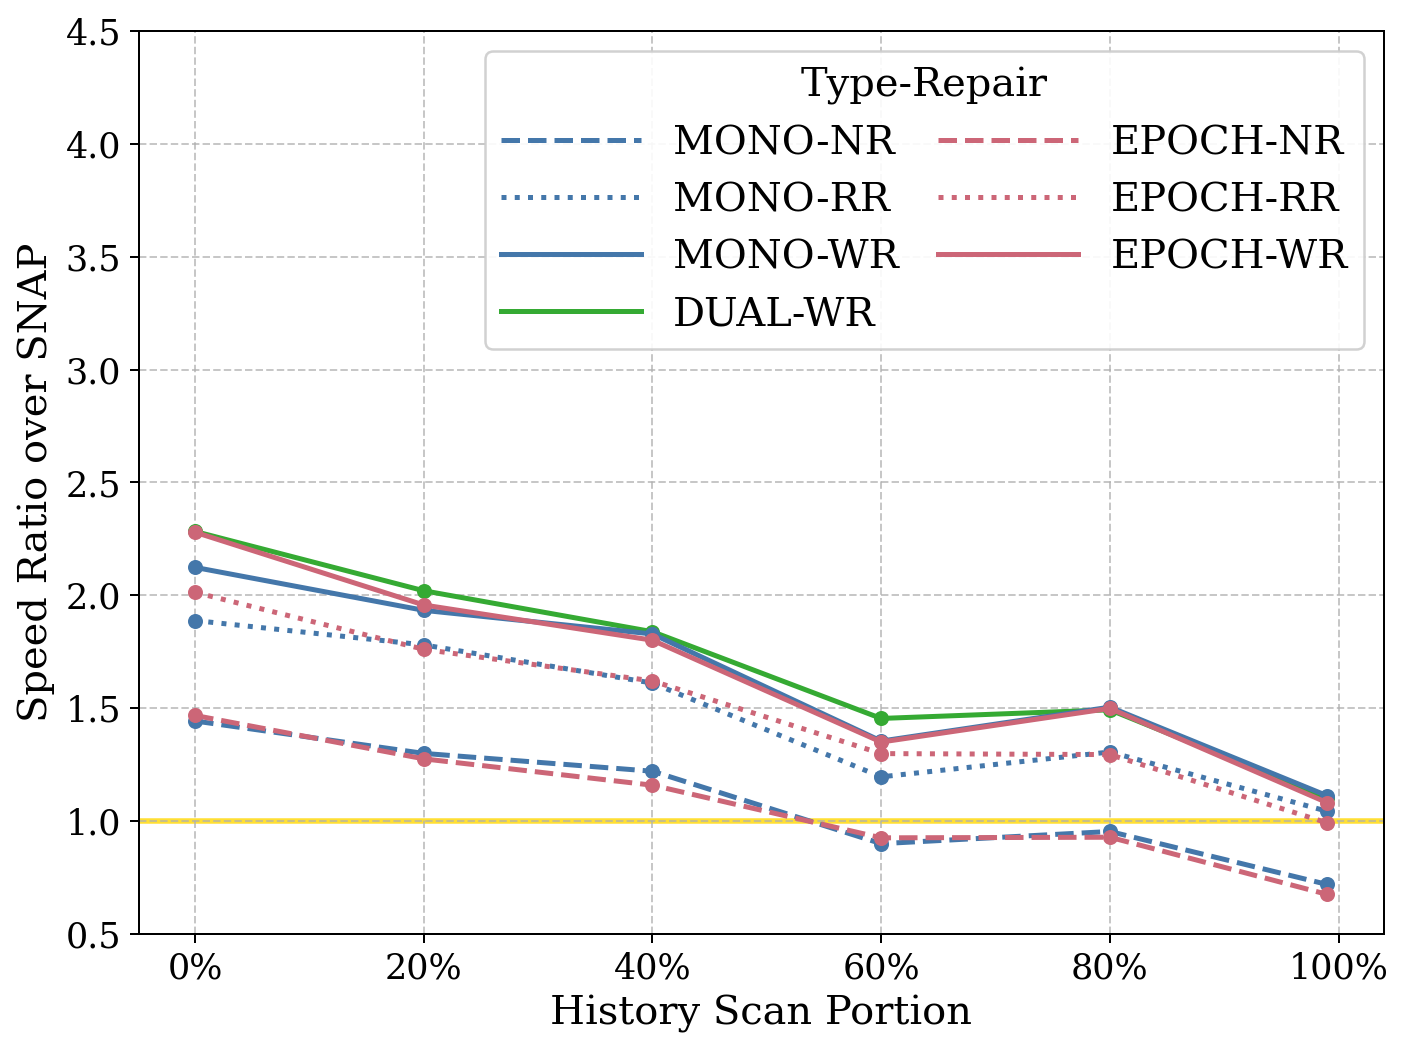

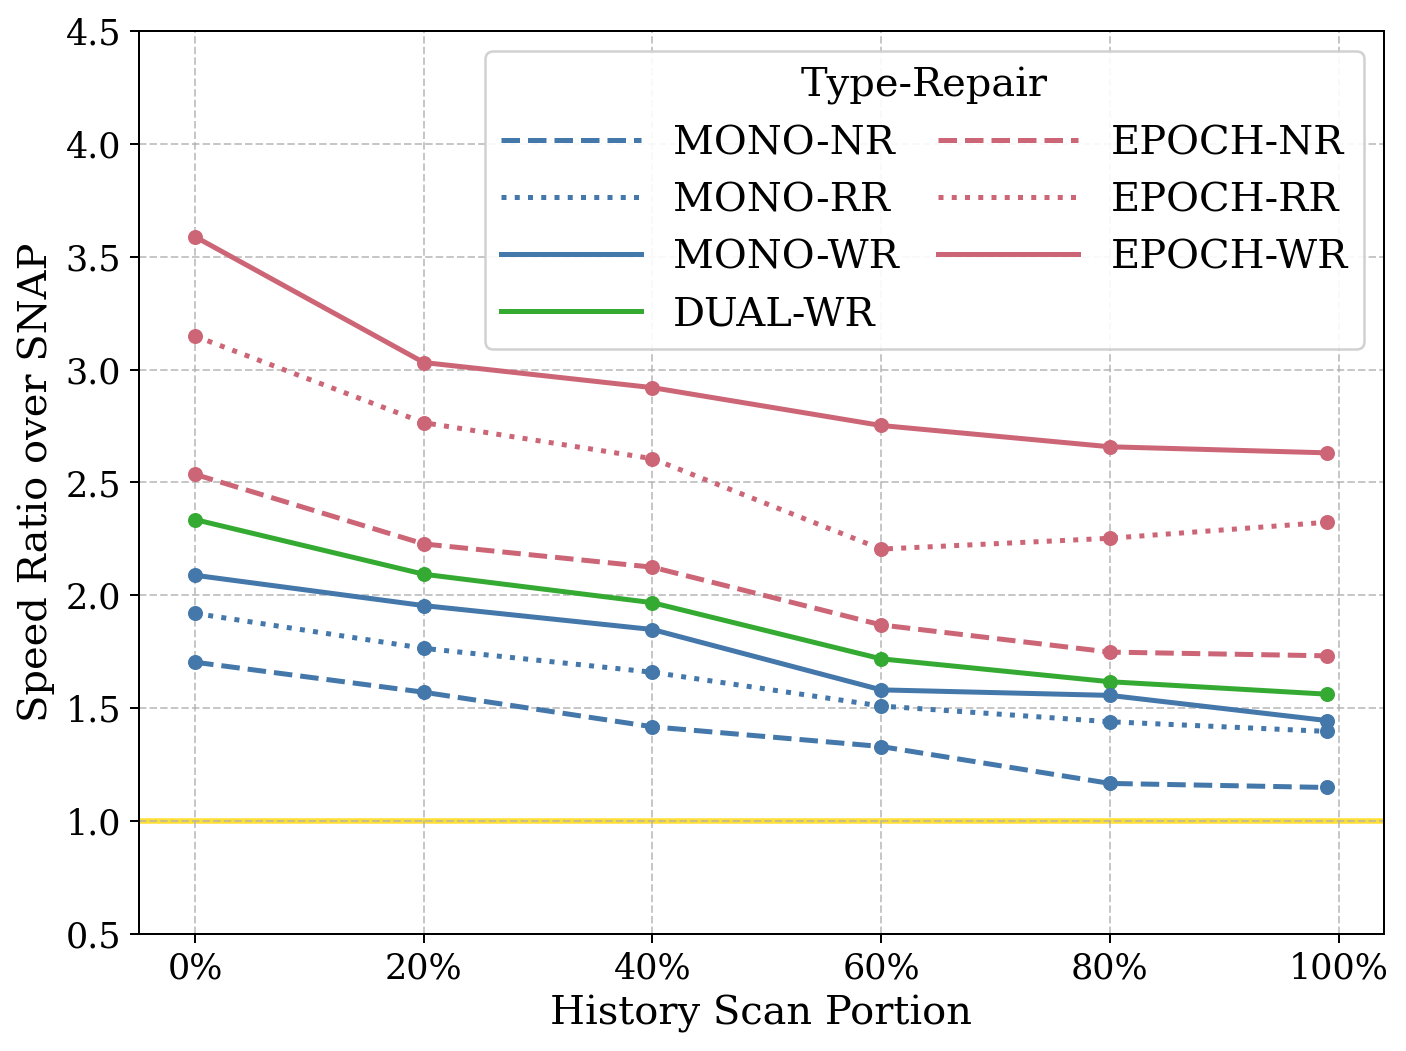

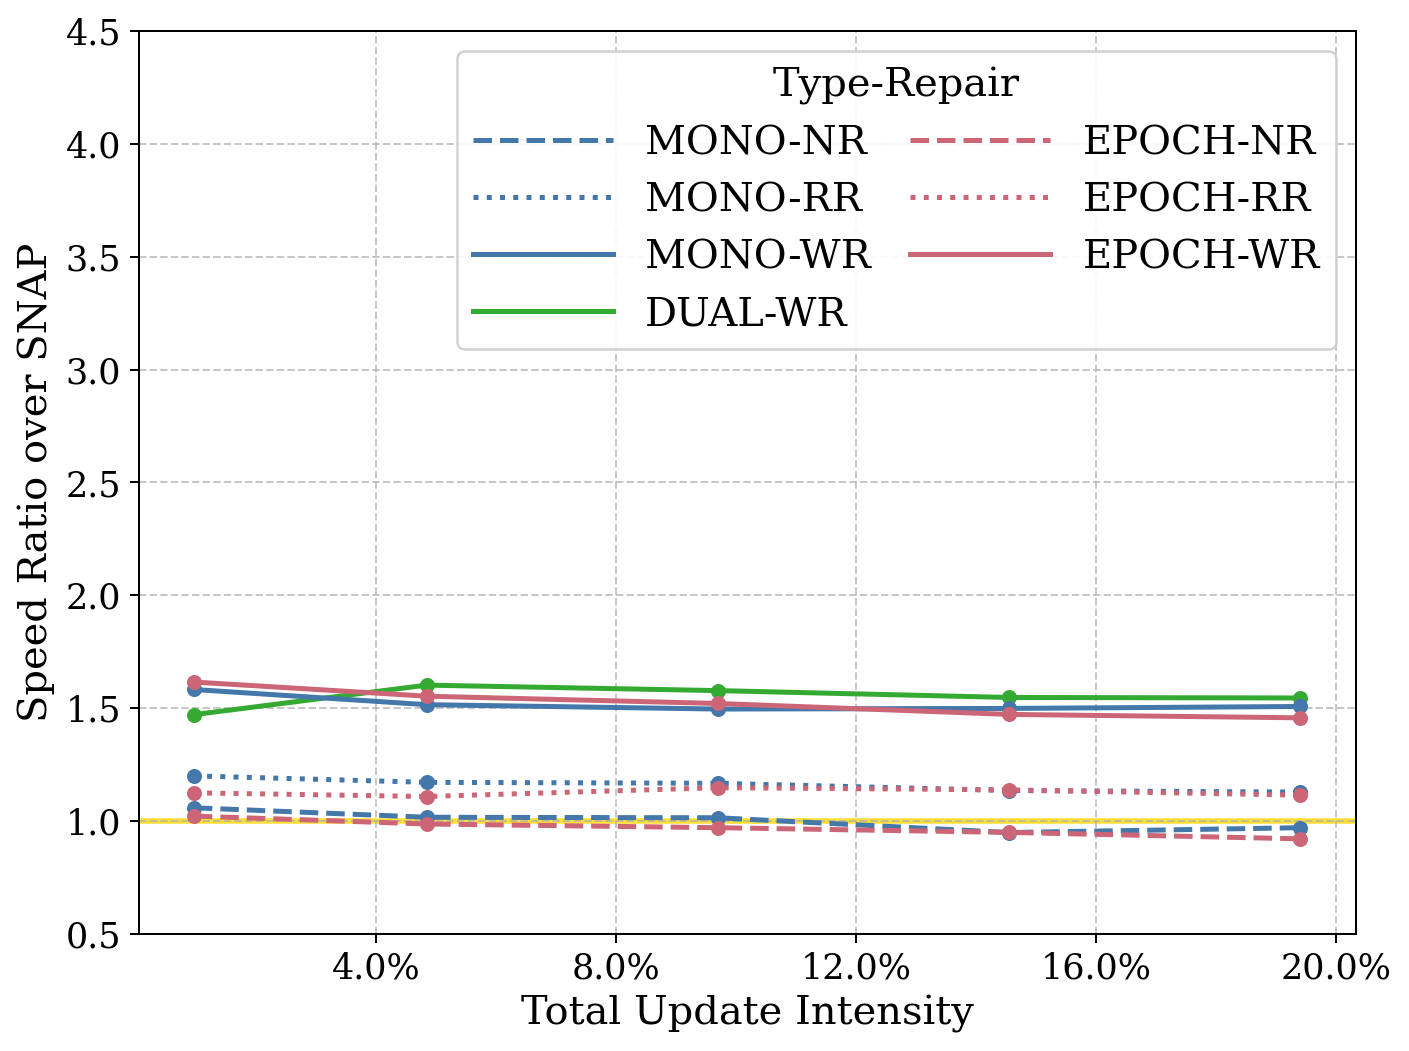

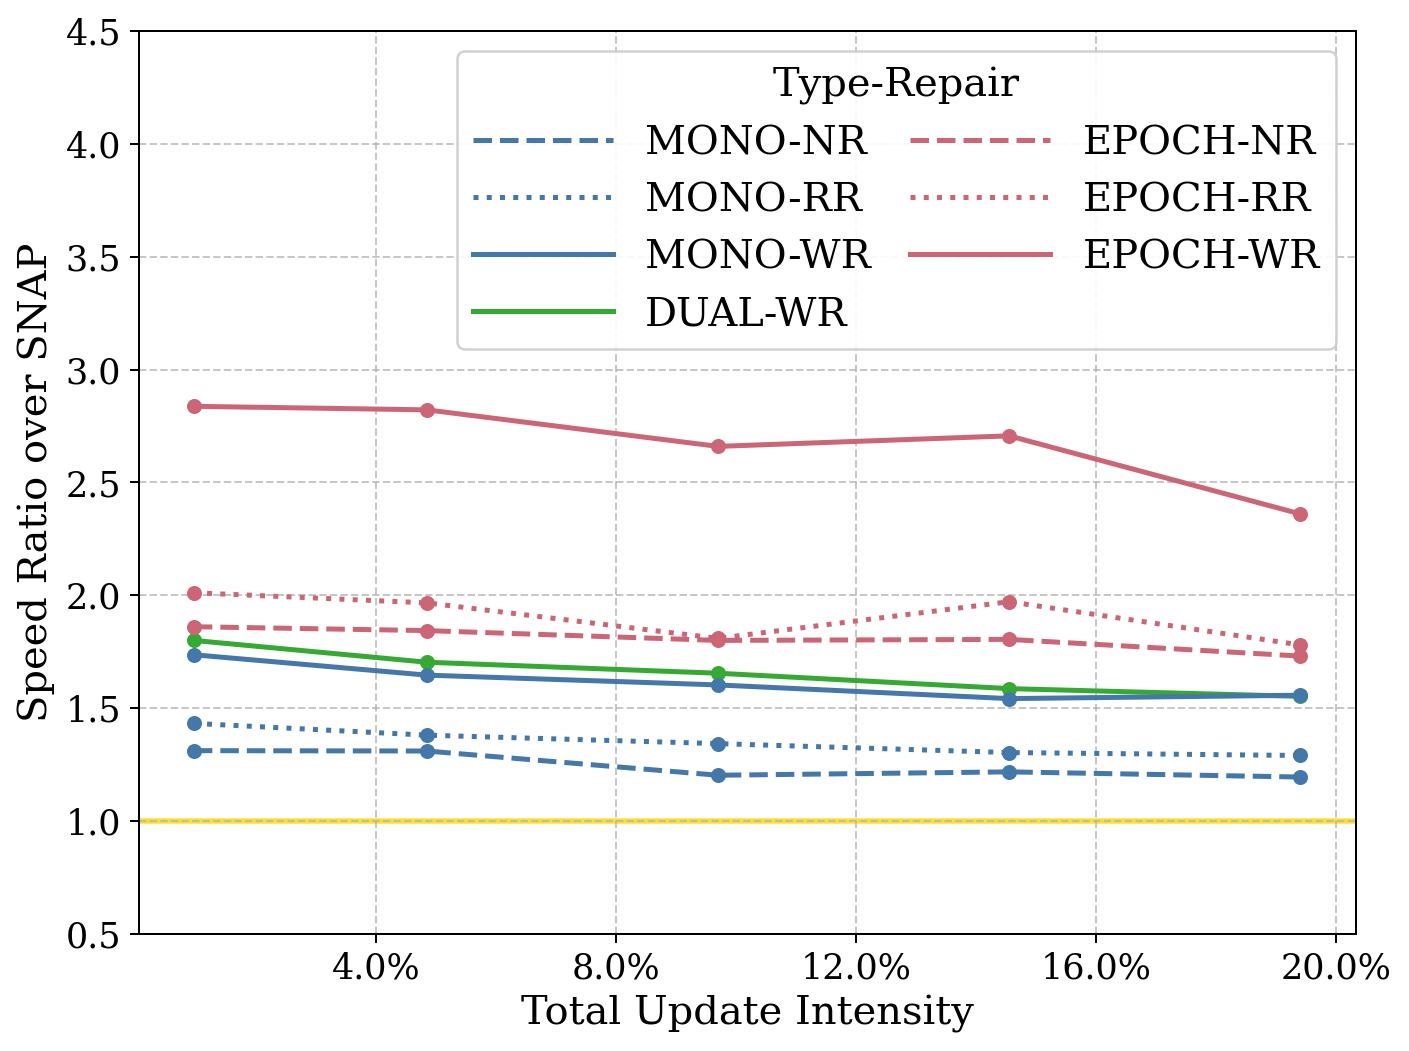

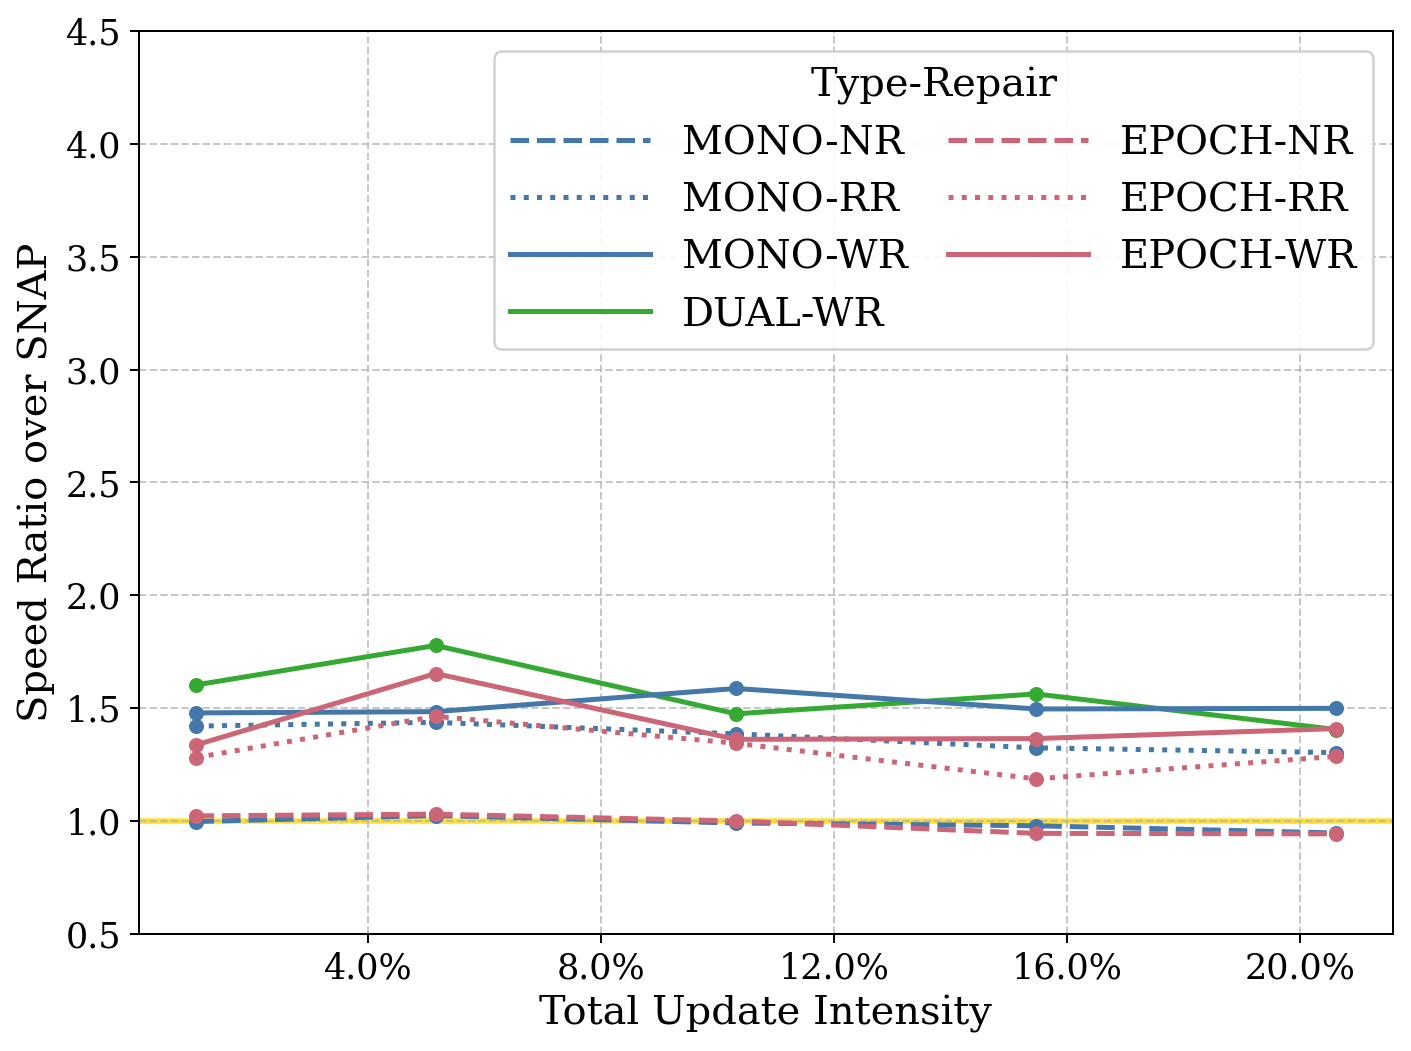

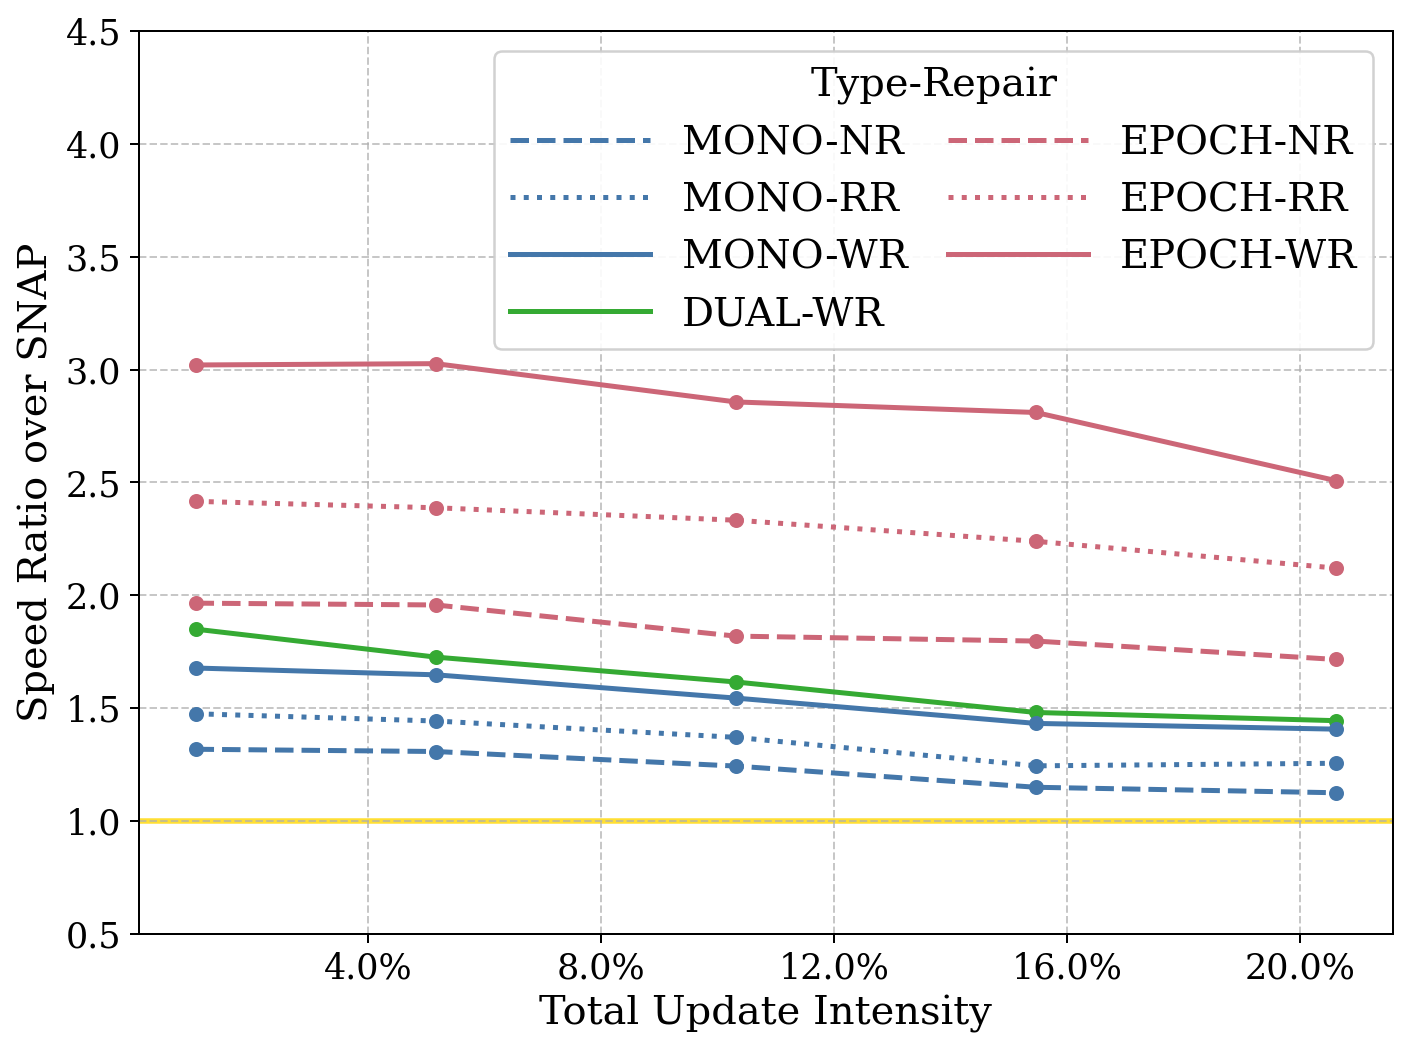

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mtick


plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,       
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 180,
    "savefig.dpi": 600     
})

bold = "normal"

def draw_line_plot(df, title, xaxis, xlabel, ylim, path="output/"):
    # === 映射与简化 ===
    table_display = {"heap": "MONO", "par": "EPOCH", "chain": "DUAL"}
    repair_display = {"No Repair": "NR", "Read Repair": "RR", "Write Repair": "WR"}

    df["table_type"] = df["table_type"].map(table_display)
    df["repair_type"] = df["repair_type"].map(repair_display)

    # === 配色与线型方案 ===
    color_map = {"MONO": "#4477AA", "EPOCH": "#CC6677", "DUAL": "#35AA33"}
    linestyle_map = {"NR": "dashed", "RR": "dotted", "WR": "-"}

    # === 统一字体和线条参数 ===
    FONT_SIZE = 16          # tick labels, axis labels
    TITLE_SIZE = 18         # figure title
    LEGEND_SIZE = 16        # legend text
    AXIS_TITLE_WEIGHT = bold
    LINE_WIDTH = 2        # line thickness
    MARKER_SIZE = 5        # larger markers

    plt.figure(figsize=(8, 6))

    for table in df["table_type"].unique():
        subdf = df[df["table_type"] == table]
        for repair in subdf["repair_type"].unique():
            data = subdf[subdf["repair_type"] == repair]
            linestyle = linestyle_map[repair]
            if table == "DUAL":
                linestyle = "-"
            plt.plot(
                data[xaxis],
                data["speed_ratio_over_naive"],
                label=f"{table}-{repair}",
                color=color_map[table],
                linestyle=linestyle,
                linewidth=LINE_WIDTH,
                marker="o",
                markersize=MARKER_SIZE,
                # markeredgecolor="black",   # add black outline to markers
                # markeredgewidth=0.8
            )
    

    # 在 plt.xticks(...) 之后添加：
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1)) 
    # === Axis styling ===
    plt.xlabel(xlabel, fontsize=FONT_SIZE, fontweight=AXIS_TITLE_WEIGHT)
    plt.ylabel("Speed Ratio over SNAP", fontsize=FONT_SIZE, fontweight=AXIS_TITLE_WEIGHT)
    plt.grid(True, linestyle="--", linewidth=0.8, alpha=0.7)
    plt.ylim(ylim)
    plt.xticks(fontsize=FONT_SIZE - 2) # , fontweight=bold
    plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=6))
    plt.yticks(fontsize=FONT_SIZE - 2)

    # === 自定义 legend 结构 ===
    legend_handles = []
    legend_labels = []
    order = ["NR", "RR", "WR"]

    for table in ["MONO"]:
        for repair in order:
            legend_handles.append(Line2D(
                [0], [0],
                color=color_map[table],
                linestyle=linestyle_map[repair],
                linewidth=LINE_WIDTH
            ))
            legend_labels.append(f"{table}-{repair}")

    legend_handles.append(Line2D([0], [0], color=color_map["DUAL"], linestyle="-", linewidth=LINE_WIDTH))
    legend_labels.append("DUAL-WR")

    for table in ["EPOCH"]:
        for repair in order:
            legend_handles.append(Line2D(
                [0], [0],
                color=color_map[table],
                linestyle=linestyle_map[repair],
                linewidth=LINE_WIDTH
            ))
            legend_labels.append(f"{table}-{repair}")

    loc = "upper right"
    if xlabel == "Delta Scan Portion":
        loc = "upper left"

    leg = plt.legend(
        legend_handles,
        legend_labels,
        title="Type-Repair",
        framealpha=0.9,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
        ncol=2,
        columnspacing=1.0,
        labelspacing=0.5,
        borderpad=0.4,
        handlelength=3.5,
        loc=loc
    )

    leg.get_title().set_fontweight(bold) 
    for text in leg.get_texts():
        text.set_fontweight(bold)

    # === Reference line ===
    plt.axhline(
        y=1.0,
        color="#FFD700",     # gold instead of yellow
        linestyle="solid",
        linewidth=2.2,
        alpha=0.8,
        zorder=0
    )

    plt.tight_layout()
    plt.savefig(path + title + ".pdf", format="pdf", bbox_inches="tight")
    plt.show()
WKLD_MAPS = {
    "DELTASC-RH": "output/(UNIFORM-ANALYTICAL) DELTA_SCAN_analyticalRatio0.8_result.csv",
    "DELTASC-RE": "output/(UNIFORM-ANALYTICAL) DELTA_SCAN_analyticalRatio0.95_result.csv",
    "REUSESC-RH-NoD": "output/(UNIFORM-ANALYTICAL) REUSE_OF_TIME_analyticalRatio0.8_deltaRatio0.0_result.csv",
    "REUSESC-RH-WithD": "output/(UNIFORM-ANALYTICAL) REUSE_OF_TIME_analyticalRatio0.8_deltaRatio0.25_result.csv",
    "REUSESC-RE-NoD": "output/(UNIFORM-ANALYTICAL) REUSE_OF_TIME_analyticalRatio0.95_deltaRatio0.0_result.csv",
    "REUSESC-RE-WithD": "output/(UNIFORM-ANALYTICAL) REUSE_OF_TIME_analyticalRatio0.95_deltaRatio0.25_result.csv",
    "UPDATE-RH-NoD":"output/(UNIFORM-ANALYTICAL) UPDATE_analyticalRatio0.8_removeDeltaTrue_result.csv",
    "UPDATE-RH-WithD":"output/(UNIFORM-ANALYTICAL) UPDATE_analyticalRatio0.8_removeDeltaFalse_result.csv",
    "UPDATE-RE-NoD":"output/(UNIFORM-ANALYTICAL) UPDATE_analyticalRatio0.95_removeDeltaTrue_result.csv",
    "UPDATE-RE-WithD":"output/(UNIFORM-ANALYTICAL) UPDATE_analyticalRatio0.95_removeDeltaFalse_result.csv",
}

XAXIS_MAPS = {
    "DELTASC-RH": "txn_delta_ratio",
    "DELTASC-RE": "txn_delta_ratio",
    "REUSESC-RH-NoD": "scan_reuse_ratio",
    "REUSESC-RH-WithD": "scan_reuse_ratio",
    "REUSESC-RE-NoD": "scan_reuse_ratio",
    "REUSESC-RE-WithD": "scan_reuse_ratio",
    "UPDATE-RH-NoD": "update_ratio",
    "UPDATE-RH-WithD": "update_ratio",
    "UPDATE-RE-NoD": "update_ratio",
    "UPDATE-RE-WithD": "update_ratio",
}

X_AXIS_TITLE = {
    "txn_delta_ratio": "Delta Scan Portion",
    "scan_reuse_ratio": "History Scan Portion",
    "update_ratio": "Total Update Intensity",
}

YLIM = {
    "txn_delta_ratio": (0.8, 3.6),
    "scan_reuse_ratio": (0.6, 4.0),
    "update_ratio": (0.75, 3.5),
}

for (title, df_path) in WKLD_MAPS.items():
    # Load CSV into a DataFrame
    df = pd.read_csv(df_path)
    # display(df)
    xaxis = XAXIS_MAPS[title]
    xlabel = X_AXIS_TITLE[xaxis]
    ylim = YLIM[xaxis]
    draw_line_plot(df, title=title, xaxis=xaxis, ylim = (0.5, 4.5), xlabel=xlabel)

# Heat Map

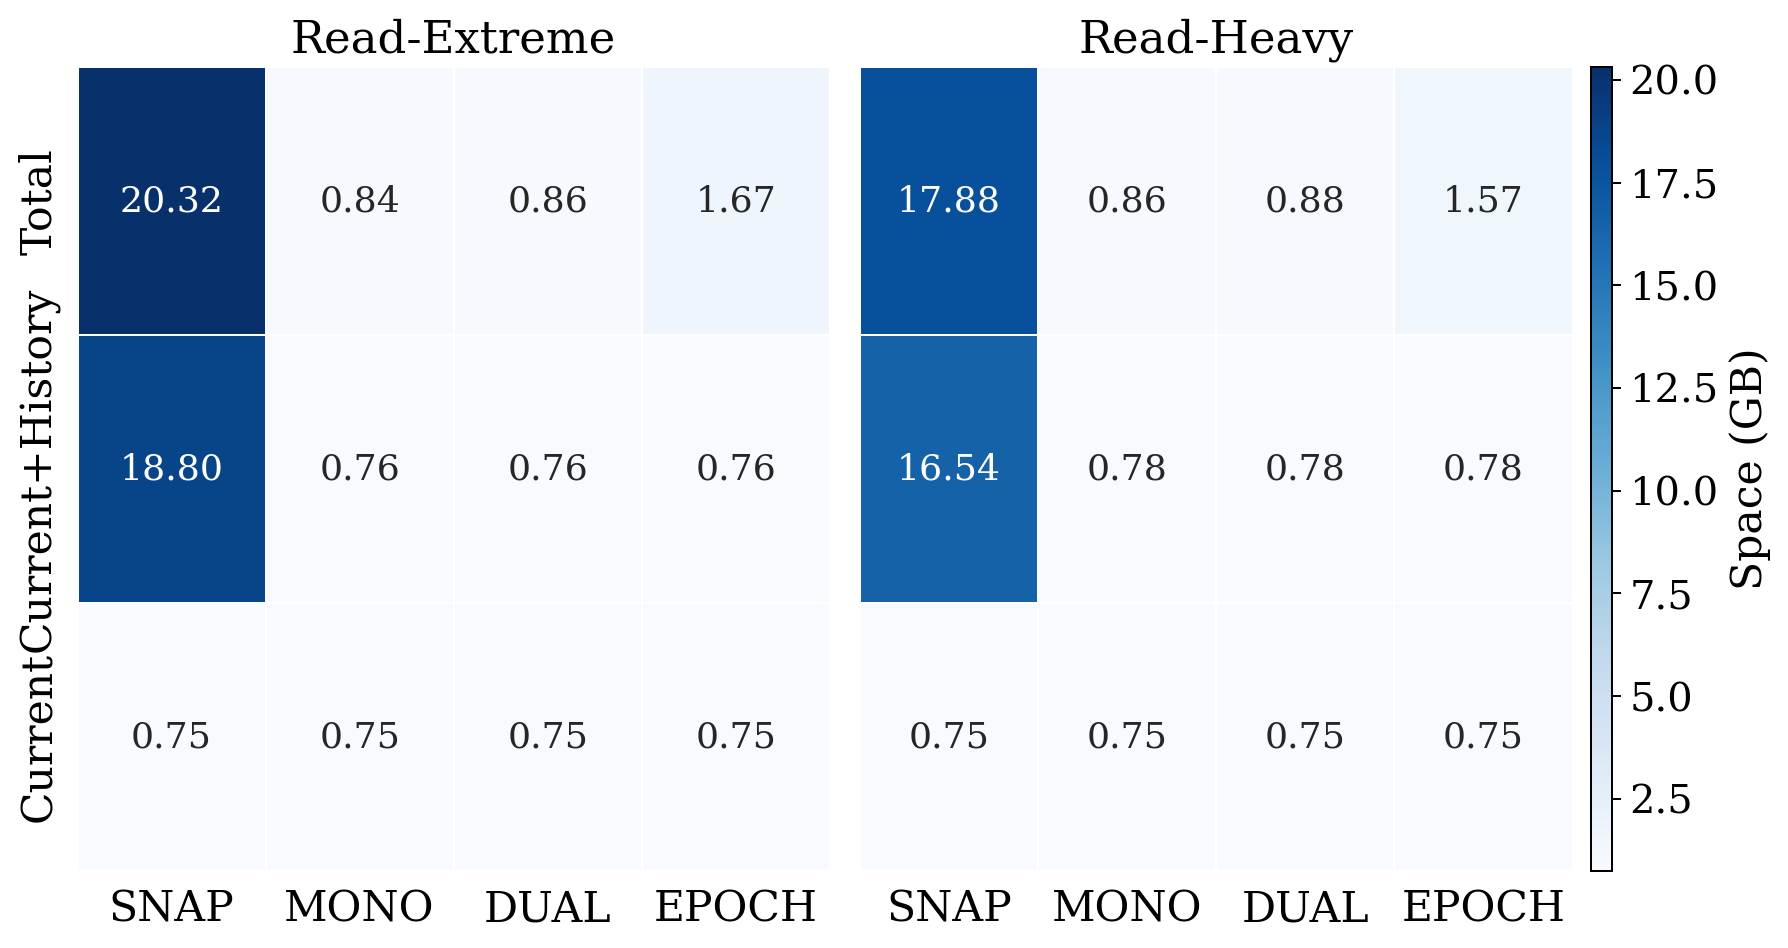

In [32]:
import os
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable 

bold = "normal"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,       
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 180,
    "savefig.dpi": 600     
})

def _auto_unit(max_val: float):
    units = [("TB", 1e12), ("GB", 1e9), ("MB", 1e6), ("KB", 1e3), ("bytes", 1.0)]
    for name, factor in units:
        if max_val >= factor:
            return name, factor
    return "bytes", 1.0

def draw_heat_map(
    df,
    path="output/",
    figsize=(11.0, 5.8),   
    panel_gap=0.04,        
    cbar_size="3%",        
    cbar_pad=0.015,        
    scale="auto"   
):
    # Pivot -> rows: metrics, columns: (workload, table_type)
    pivot = df.pivot_table(
        index=["workload", "table_type"],
        values=["total_space", "all_versions_space", "valid_space"],
        aggfunc="first"
    ).T

    # Row order
    pivot = pivot.loc[["total_space", "all_versions_space", "valid_space"]]

    # Column order
    workloads   = ["R-Extreme", "R-Heavy"]
    table_types = ["SNAP", "MONO", "DUAL", "EPOCH"]
    desired_cols = pd.MultiIndex.from_product([workloads, table_types], names=["workload", "table_type"])
    pivot = pivot.reindex(columns=desired_cols)

    # Pretty row labels
    pivot = pivot.rename(index={
        "total_space": "Total",
        "all_versions_space": "Current+History",
        "valid_space": "Current",
    })

    # Scaling 
    max_val = float(np.nanmax(pivot.values))
    if isinstance(scale, (int, float)):
        factor = float(scale)
        unit_label = "×1e8 bytes" if abs(factor - 1e8) < 1e-9 else f"bytes ÷ {factor:g}"
    else:
        unit_label, factor = _auto_unit(max_val)
    scaled = pivot / factor

    # Split panels
    left  = scaled.loc[:, ("R-Extreme", slice(None))]
    left.columns  = left.columns.get_level_values("table_type")
    right = scaled.loc[:, ("R-Heavy", slice(None))]
    right.columns = right.columns.get_level_values("table_type")

    vmin = np.nanmin(scaled.values)
    vmax = np.nanmax(scaled.values)

    ann_left  = np.vectorize(lambda x: f"{x:.2f}")(left.values)
    ann_right = np.vectorize(lambda x: f"{x:.2f}")(right.values)

    os.makedirs(path, exist_ok=True)

    fig = plt.figure(figsize=figsize)
    gs  = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1, 1], wspace=panel_gap)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])

    # Font scaling constants
    FONT_BASE = 17        # base font size for labels
    FONT_TITLE = 18       # title font size
    FONT_ANNOT = 14.5       # annotation (numbers inside heatmap)
    FONT_CBAR = 17        # colorbar label and ticks

    # --- Left heatmap ---
    hm0 = sns.heatmap(
        left, ax=ax0,
        annot=ann_left, fmt="", cmap="Blues",
        linewidths=0.6, linecolor="white",
        cbar=False, vmin=vmin, vmax=vmax,
        annot_kws={"fontsize": FONT_ANNOT, "fontweight": bold}
    )
    ax0.set_title("Read-Extreme", fontsize=FONT_TITLE, fontweight=bold)
    ax0.set_xlabel("")
    ax0.set_ylabel("")
    ax0.set_xticklabels(ax0.get_xticklabels(), rotation=0, fontsize=FONT_BASE, fontweight=bold)
    ax0.tick_params(axis='y', labelsize=FONT_BASE, left=False, right=False)
    ax0.tick_params(axis='x', bottom=False, top=False)

    # --- Right heatmap ---
    hm1 = sns.heatmap(
        right, ax=ax1,
        annot=ann_right, fmt="", cmap="Blues",
        linewidths=0.6, linecolor="white",
        cbar=False, vmin=vmin, vmax=vmax,
        annot_kws={"fontsize": FONT_ANNOT, "fontweight": bold}
    )
    ax1.set_title("Read-Heavy", fontsize=FONT_TITLE, fontweight=bold)
    ax1.set_xlabel("")
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, fontsize=FONT_BASE, fontweight=bold)
    ax1.tick_params(axis='x', bottom=False, top=False)
    ax1.set_ylabel("")
    ax1.set_yticklabels(
        ax0.get_yticklabels(),
        rotation=0,
        fontsize=FONT_BASE,   # ✅ 这里改字体大小
        fontweight=bold       # ✅ 如果需要加粗，这里生效
    )
    ax1.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    ax1.spines['left'].set_visible(False)
    ax1.set_yticks([])
    ax1.set_ylim(ax0.get_ylim())

    # --- Colorbar ---
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size=cbar_size, pad=cbar_pad)
    cbar = fig.colorbar(hm1.collections[0], cax=cax)
    cbar.set_label(f"Space ({unit_label})", fontsize=FONT_CBAR, fontweight=bold)
    sf = ScalarFormatter(useMathText=False)
    sf.set_scientific(False)
    cbar.ax.yaxis.set_major_formatter(sf)
    cbar.ax.tick_params(labelsize=FONT_CBAR - 1)
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight(bold)

    out_pdf = os.path.join(path, "SpaceStatistics.pdf")
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
    plt.show()

# -------------------------
# Example usage
# -------------------------
TITLE_MAP = {
    "R-Heavy":   "(UNIFORM-ANALYTICAL) R-Heavy SpaceStatistics_spaceStatistics" + "_result.csv",
    "R-Extreme": "(UNIFORM-ANALYTICAL) R-Extrme SpaceStatistics_spaceStatistics" + "_result.csv",  
}

df_final = pd.DataFrame()
for title, name in TITLE_MAP.items():
    df_path = "output/" + name
    df = pd.read_csv(df_path)
    df["workload"] = title
    df_final = pd.concat([df_final, df], ignore_index=True)

draw_heat_map(
    df_final,
    figsize=(11.0, 5.8),  
    panel_gap=0.04,    
    cbar_size="3%",
    cbar_pad=0.1,     
    scale="auto"
)

# Bars

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,naive,1155.457320,1050000.0,NaN,NaN,NaN
1,0,0,InitLoad,Read Repair,naive,816.821689,1050000.0,NaN,NaN,NaN
2,0,0,InitLoad,Write Repair,naive,822.902266,1050000.0,NaN,NaN,NaN
3,1,1,Update,No Repair,naive,14.178778,21000.0,NaN,NaN,NaN
4,1,1,Update,Read Repair,naive,13.896192,21000.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
247,12,12,Probe,Read Repair,chain,213.977458,105.0,13.0,NaN,NaN
248,12,12,Probe,Write Repair,chain,217.866319,105.0,13.0,NaN,NaN
249,13,13,GbgCollect,No Repair,chain,1.518390,NaN,2.0,NaN,NaN
250,13,13,GbgCollect,Read Repair,chain,1.613071,NaN,2.0,NaN,NaN


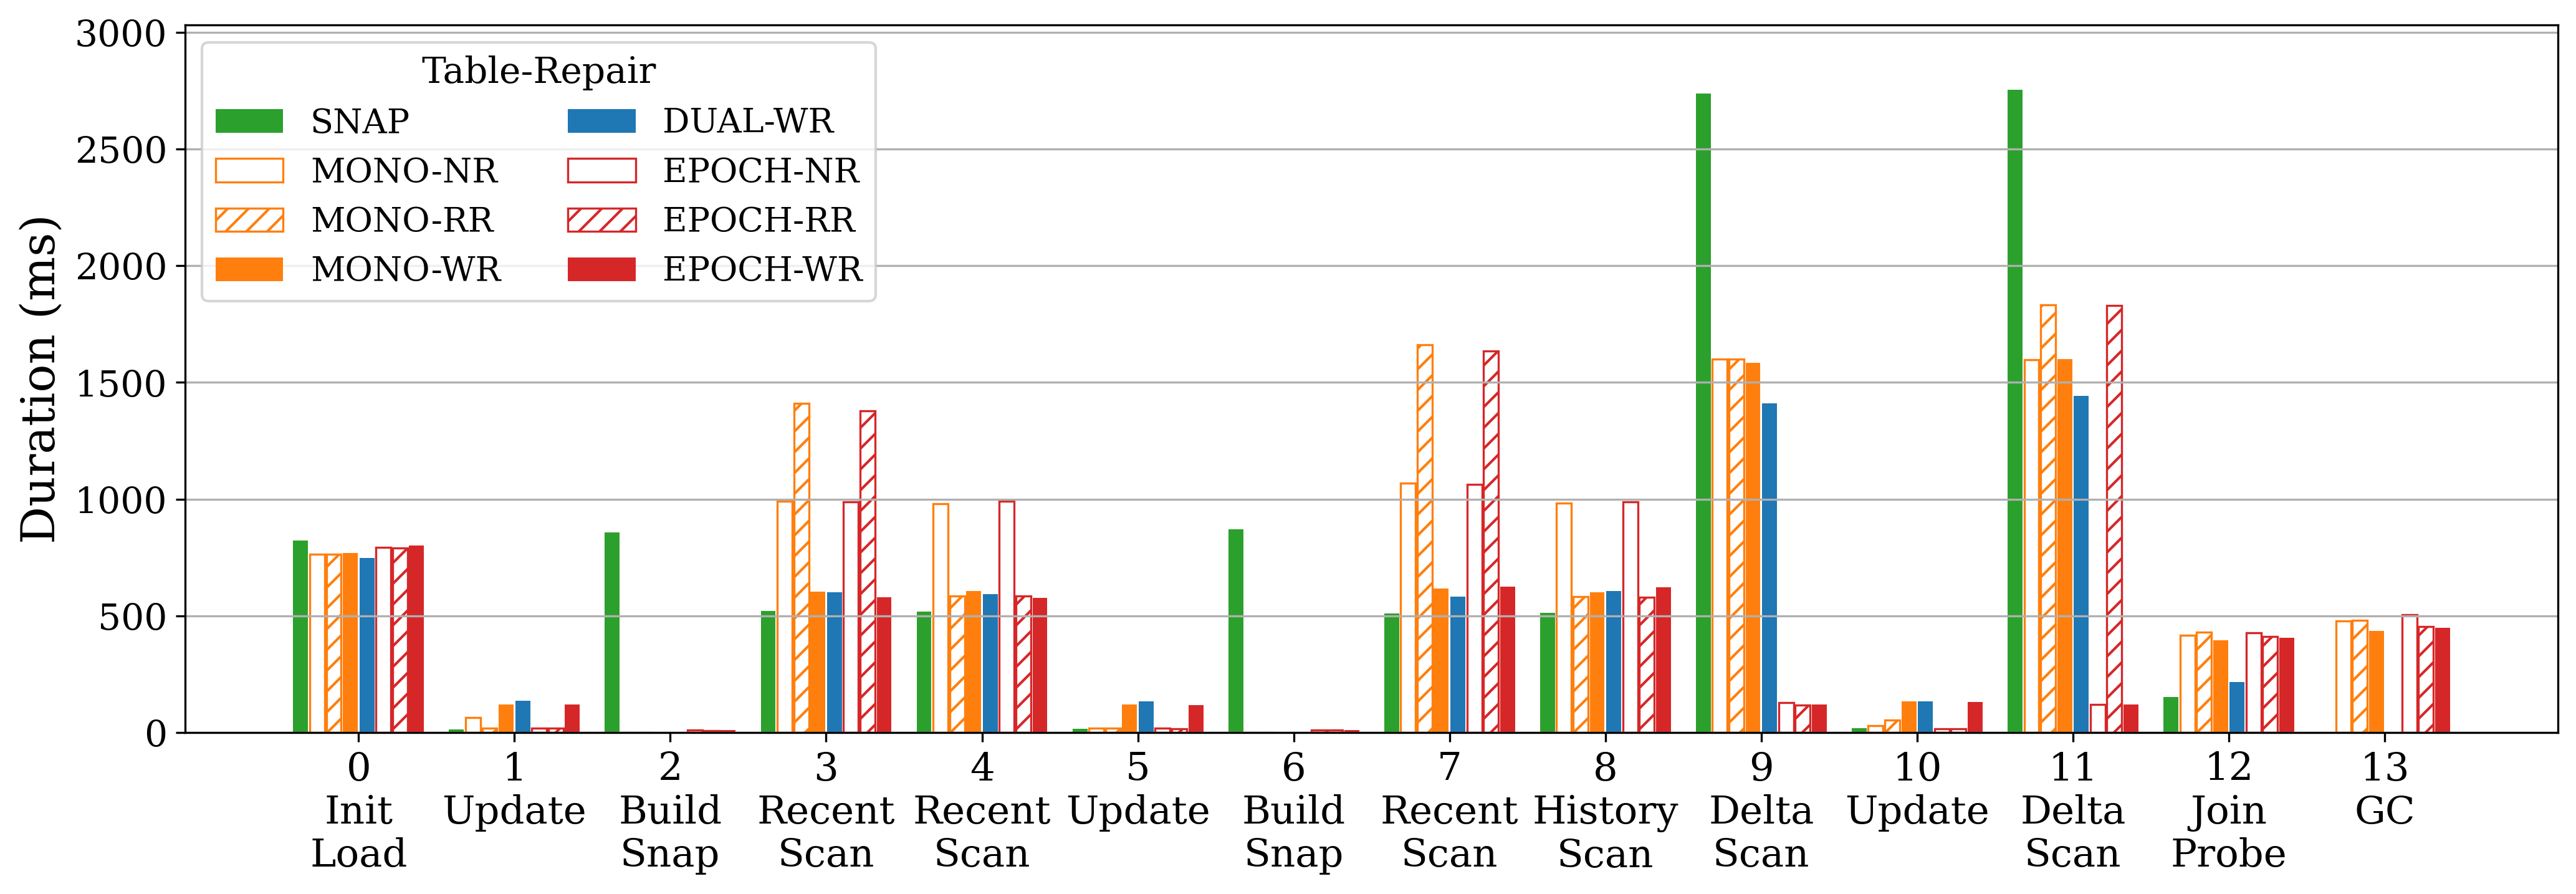

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

TX_MAP = {
        "MarkTs": "Build\nSnap",
        "DelSc": "Delta\nScan",
        "RecentScan": "Recent\nScan",
        "HistoryScan": "History\nScan",
        "GbgCollect": "GC",
        "Probe": "Join\nProbe",
        "Update": "Update",
        "InitLoad": "Init\nLoad"
    }
def replace_with_map(label, mapping):
    for k, v in mapping.items():
        if k in label:
            return label.replace(k, v)
    return label



# =========================
# 🔧 全局样式配置接口
# =========================
STYLE_CONFIG = {
    "font_family": "serif",
    "font_serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font_size": 14,         # 全局字体基础大小
    "title_size": 18,        # 主标题字体
    "axis_label_size": 18,   # 坐标轴标题字体
    "tick_label_size": 15,   # 坐标轴刻度标签字体
    "legend_size": 13,       # 图例字体
    "legend_title_size": 14, # 图例标题字体
    "bold": False,           # 是否加粗（你选择了0，即False）
    "dpi": 300               # 输出分辨率
}

def apply_style(config):
    fontweight = 'bold' if config["bold"] else 'normal'
    plt.rcParams.update({
        "font.family": config["font_family"],
        "font.serif": config["font_serif"],
        "font.size": config["font_size"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.dpi": config["dpi"],
        "savefig.dpi": config["dpi"]
    })
    return fontweight


# =========================
# 绘图辅助函数
# =========================
def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }

def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:
            ax.text(
                x,
                y,
                f"{y:.0f}",
                ha='center',
                va='bottom',
                fontsize=font_size
            )


# =========================
# 主绘图函数（带样式接口）
# =========================
from bench_script_functions import prepare_plot_data

def plot_all(df, title="Transaction Duration", path="./output/"):
    # 应用样式配置
    fontweight = apply_style(STYLE_CONFIG)
    
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, _ = prepare_plot_data(df)
    x_labels = [replace_with_map(label, TX_MAP) for label in x_labels]
    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 1.0), 5))

    table_order   = ["naive", "heap", "chain", "par"]  # data keys
    table_display = {"naive":"SNAP", "heap":"MONO", "chain":"DUAL", "par":"EPOCH"}

    repair_display = {"No Repair":"NR", "Read Repair":"RR", "Write Repair":"WR", "": ""}

    groups = []
    ordered_layout = [
        ("naive", ["Write Repair"]),                                      # SNAP (no suffix)
        ("heap",  ["No Repair", "Read Repair", "Write Repair"]),  # MONO
        ("chain", ["Write Repair"]),                           # DUAL
        ("par",   ["No Repair", "Read Repair", "Write Repair"])   # EPOCH
    ]

    for table_type, repair_list in ordered_layout:
        for repair_type in repair_list:
            groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.85
    bar_width = group_width / num_bars_per_group
    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    duration_max = 0.0
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue
        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []
        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)
        display_name = table_display.get(table_type, table_type)
        repair_name = repair_display.get(repair_type, repair_type)
        if display_name == "SNAP":
            repair_name = ""
        label = display_name if repair_name == "" else f"{display_name}-{repair_name}"
        # label = f"{table_display.get(table_type, table_type)}-{repair_display.get(repair_type, repair_type)}"

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=label,
            **style
        )
        duration_max = max(duration_max, max(durations))
        # draw_bar_labels(ax, x_positions, durations, font_size=STYLE_CONFIG["tick_label_size"])

    max_y = duration_max * 1.1
    ax.set_ylim(0, max_y)
    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=STYLE_CONFIG["tick_label_size"])

    # ax.set_xlabel('Transaction', fontsize=STYLE_CONFIG["axis_label_size"], fontweight=fontweight)
    ax.set_ylabel('Duration (ms)', fontsize=STYLE_CONFIG["axis_label_size"], fontweight=fontweight)
    # ax.set_title(title, fontsize=STYLE_CONFIG["title_size"], fontweight=fontweight)

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        title="Table-Repair",
        fontsize=STYLE_CONFIG["legend_size"],
        title_fontsize=STYLE_CONFIG["legend_title_size"],
        ncol=2
    )

    plt.tight_layout()
    plt.savefig(f"{path}{title}.pdf", format="pdf")
    plt.show()


# =========================
# 使用示例
# =========================
TITLE_MAP = {
    "Bars": "(UNIFORM-ANALYTICAL) LONG_BARS_FullPlot_result.csv",

}

for title, name in TITLE_MAP.items():
    df_path = "output/" + name
    df = pd.read_csv(df_path)
    df = df[~df['tx_id'].between(6, 12)]

    # 将 13–20 的 tx_id 往前移 7
    df.loc[df['tx_id'] > 12, 'tx_id'] -= 7

    # 如果希望 idx 重新排序
    df['idx'] = df['tx_id']
    # df = df[df["tx_id"] <= 12]
    display(df)

    plot_all(df, title=title)
